## **Data Cleaning**

In [123]:
from pyspark.sql import SparkSession

# Start a Spark session
spark = SparkSession.builder.appName("JobPostingsAnalysis").getOrCreate()

# Load the CSV file into a Spark DataFrame
df = spark.read.option("header", "true").option("inferSchema", "true").option("multiLine","true").option("escape", "\"").csv("/home/ubuntu/job-market-analysis-project-2026/data/lightcast_job_postings.csv")

# Show schema
df.printSchema()

root
 |-- ID: string (nullable = true)
 |-- LAST_UPDATED_DATE: string (nullable = true)
 |-- LAST_UPDATED_TIMESTAMP: timestamp (nullable = true)
 |-- DUPLICATES: integer (nullable = true)
 |-- POSTED: string (nullable = true)
 |-- EXPIRED: string (nullable = true)
 |-- DURATION: integer (nullable = true)
 |-- SOURCE_TYPES: string (nullable = true)
 |-- SOURCES: string (nullable = true)
 |-- URL: string (nullable = true)
 |-- ACTIVE_URLS: string (nullable = true)
 |-- ACTIVE_SOURCES_INFO: string (nullable = true)
 |-- TITLE_RAW: string (nullable = true)
 |-- BODY: string (nullable = true)
 |-- MODELED_EXPIRED: string (nullable = true)
 |-- MODELED_DURATION: integer (nullable = true)
 |-- COMPANY: integer (nullable = true)
 |-- COMPANY_NAME: string (nullable = true)
 |-- COMPANY_RAW: string (nullable = true)
 |-- COMPANY_IS_STAFFING: boolean (nullable = true)
 |-- EDUCATION_LEVELS: string (nullable = true)
 |-- EDUCATION_LEVELS_NAME: string (nullable = true)
 |-- MIN_EDULEVELS: integer (

In [1]:
# Only applicable to Shuyu's environment, delete when writing the reports
from pyspark.sql import SparkSession

# Start a Spark session
spark = SparkSession.builder.appName("JobPostingsAnalysis").getOrCreate()

# Load the CSV file into a Spark DataFrame
df = spark.read.option("header", "true").option("inferSchema", "true").option(
    "multiLine", "true").option("escape", "\"").csv("data/lightcast_job_postings.csv")

df.printSchema()
df.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/29 22:27:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


root
 |-- ID: string (nullable = true)
 |-- LAST_UPDATED_DATE: string (nullable = true)
 |-- LAST_UPDATED_TIMESTAMP: timestamp (nullable = true)
 |-- DUPLICATES: integer (nullable = true)
 |-- POSTED: string (nullable = true)
 |-- EXPIRED: string (nullable = true)
 |-- DURATION: integer (nullable = true)
 |-- SOURCE_TYPES: string (nullable = true)
 |-- SOURCES: string (nullable = true)
 |-- URL: string (nullable = true)
 |-- ACTIVE_URLS: string (nullable = true)
 |-- ACTIVE_SOURCES_INFO: string (nullable = true)
 |-- TITLE_RAW: string (nullable = true)
 |-- BODY: string (nullable = true)
 |-- MODELED_EXPIRED: string (nullable = true)
 |-- MODELED_DURATION: integer (nullable = true)
 |-- COMPANY: integer (nullable = true)
 |-- COMPANY_NAME: string (nullable = true)
 |-- COMPANY_RAW: string (nullable = true)
 |-- COMPANY_IS_STAFFING: boolean (nullable = true)
 |-- EDUCATION_LEVELS: string (nullable = true)
 |-- EDUCATION_LEVELS_NAME: string (nullable = true)
 |-- MIN_EDULEVELS: integer (

26/04/29 22:28:05 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------+-----------------+----------------------+----------+--------+---------+--------+--------------------+--------------------+--------------------+-----------+-------------------+--------------------+--------------------+---------------+----------------+--------+--------------------+-----------+-------------------+----------------+---------------------+-------------+-------------------+-------------+------------------+---------------+--------------------+--------------------+--------------------+-------------+------+-----------+----------------+-------------------+---------+-----------+--------------------+--------------------+-------------+------+--------------+-----+--------------------+-----+----------+---------------+--------------------+---------------+--------------------+------------+--------------------+------------+--------------------+------+--------------------+------+--------------------+------+--------------------+------+--------------------+------+------

**Column Selection and Feature Reduction**

The original dataset contains a wide range of variables encompassing job characteristics, classification systems, metadata, and raw textual fields. To ensure analytical clarity and methodological rigor, a systematic feature selection process was undertaken to remove irrelevant, redundant, and excessively granular variables.

First, variables associated with metadata and system-level identifiers were excluded. These include fields such as ID, URL, SOURCES, and timestamp-related columns, which primarily serve operational or tracking purposes rather than contributing meaningful information for analysis. Similarly, raw text fields such as TITLE_RAW and COMPANY_RAW were removed in favor of their cleaned or standardized counterparts, such as TITLE_CLEAN, which provide greater consistency and are more suitable for downstream analysis.

Second, the dataset includes multiple occupational and industry classification systems, including NAICS, SOC, CIP, ONET, and Lightcast’s proprietary taxonomy. While each system provides a structured representation of job and industry characteristics, there is substantial conceptual overlap among them. To reduce redundancy and mitigate the risk of multicollinearity, a single, coherent set of classification variables was selected. Specifically, NAICS2_NAME was retained to represent industry at an aggregate and interpretable level, while LOT_OCCUPATION_NAME and LOT_CAREER_AREA_NAME were used to capture occupational roles and broader career domains. Other classification systems such as SOC, ONET, and CIP were excluded, as they duplicate information already captured by the selected variables without providing additional analytical value.

Furthermore, multiple levels and versions of NAICS codes, including NAICS3 through NAICS6 and NAICS_2022_*, were removed. These variables reflect a hierarchical structure in which more granular levels are nested within broader categories. Including multiple levels simultaneously would introduce redundant information and unnecessarily increase model complexity. Retaining only the 2-digit NAICS classification ensures a balance between interpretability and analytical usefulness while avoiding excessive fragmentation of categories.

Finally, highly granular and versioned taxonomy fields, such as LOT_SPECIALIZED_OCCUPATION_NAME and LOT_V6_* variables, were excluded. These fields tend to generate a large number of distinct categories, which can reduce interpretability, complicate visualization, and negatively impact model performance due to high cardinality.

Overall, this feature reduction process enhances the analytical quality of the dataset by minimizing redundancy, reducing dimensionality, and improving interpretability. By focusing on a carefully selected subset of variables, the analysis becomes more efficient, the resulting models are more stable, and the insights generated are more coherent and actionable.

**Removing Duplicates**

To ensure each job is counted only once, we remove duplicates based on job title, company, location, and posting date.

In [126]:
# select the needed columns 
cols = [
    # job roles
    "TITLE_NAME",
    "TITLE_CLEAN",
    "LOT_OCCUPATION_NAME",
    "LOT_CAREER_AREA_NAME",
    "LOT_SPECIALIZED_OCCUPATION_NAME",
    "LOT_V6_SPECIALIZED_OCCUPATION_NAME",
    "LOT_V6_CAREER_AREA_NAME",

    # skills
    "SKILLS_NAME",
    "SPECIALIZED_SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME",
    "COMMON_SKILLS_NAME",
    "CERTIFICATIONS_NAME",

    # job description
    "BODY",

    # industry
    "NAICS2_NAME",
    "NAICS_2022_2_NAME",
    "LIGHTCAST_SECTORS_NAME",
    

    # experience/education
    "MIN_YEARS_EXPERIENCE",
    "MIN_EDULEVELS_NAME",
    "EDUCATION_LEVELS_NAME", 
    "MIN_EDULEVELS",
    "IS_INTERNSHIP",

    # salary
    "SALARY",
    "SALARY_FROM",
    "SALARY_TO",

    # work setup
    "REMOTE_TYPE_NAME",
    "EMPLOYMENT_TYPE_NAME"
]
    
# remove duplicate job postings using raw columns
df = df.dropDuplicates(["TITLE", "COMPANY", "LOCATION", "POSTED"])

# then explicitly keep only needed columns
df = df.select(*cols)

In [3]:
# print the schema and display the new df
df.printSchema()
df.show(5)

root
 |-- TITLE_NAME: string (nullable = true)
 |-- TITLE_CLEAN: string (nullable = true)
 |-- LOT_OCCUPATION_NAME: string (nullable = true)
 |-- LOT_CAREER_AREA_NAME: string (nullable = true)
 |-- LOT_SPECIALIZED_OCCUPATION_NAME: string (nullable = true)
 |-- LOT_V6_SPECIALIZED_OCCUPATION_NAME: string (nullable = true)
 |-- LOT_V6_CAREER_AREA_NAME: string (nullable = true)
 |-- SKILLS_NAME: string (nullable = true)
 |-- SPECIALIZED_SKILLS_NAME: string (nullable = true)
 |-- SOFTWARE_SKILLS_NAME: string (nullable = true)
 |-- COMMON_SKILLS_NAME: string (nullable = true)
 |-- CERTIFICATIONS_NAME: string (nullable = true)
 |-- BODY: string (nullable = true)
 |-- NAICS2_NAME: string (nullable = true)
 |-- NAICS_2022_2_NAME: string (nullable = true)
 |-- LIGHTCAST_SECTORS_NAME: string (nullable = true)
 |-- MIN_YEARS_EXPERIENCE: integer (nullable = true)
 |-- MIN_EDULEVELS_NAME: string (nullable = true)
 |-- EDUCATION_LEVELS_NAME: string (nullable = true)
 |-- MIN_EDULEVELS: integer (nulla

+----------+-----------+-------------------+--------------------+-------------------------------+----------------------------------+-----------------------+-----------+-----------------------+--------------------+------------------+-------------------+----+-----------+-----------------+----------------------+--------------------+------------------+---------------------+-------------+-------------+------+-----------+---------+----------------+--------------------+
|TITLE_NAME|TITLE_CLEAN|LOT_OCCUPATION_NAME|LOT_CAREER_AREA_NAME|LOT_SPECIALIZED_OCCUPATION_NAME|LOT_V6_SPECIALIZED_OCCUPATION_NAME|LOT_V6_CAREER_AREA_NAME|SKILLS_NAME|SPECIALIZED_SKILLS_NAME|SOFTWARE_SKILLS_NAME|COMMON_SKILLS_NAME|CERTIFICATIONS_NAME|BODY|NAICS2_NAME|NAICS_2022_2_NAME|LIGHTCAST_SECTORS_NAME|MIN_YEARS_EXPERIENCE|MIN_EDULEVELS_NAME|EDUCATION_LEVELS_NAME|MIN_EDULEVELS|IS_INTERNSHIP|SALARY|SALARY_FROM|SALARY_TO|REMOTE_TYPE_NAME|EMPLOYMENT_TYPE_NAME|
+----------+-----------+-------------------+--------------------

In [4]:
# compute the percentage of missing data to assess the approach for data cleaning
from pyspark.sql.functions import col, count, when

total_rows = df.count()

missing_summary = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).toPandas().T

missing_summary.columns = ["missing_count"]
missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / total_rows * 100
)

missing_summary = missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
LIGHTCAST_SECTORS_NAME,52138,75.346108
SALARY,39959,57.745889
SALARY_TO,38494,55.628775
SALARY_FROM,38494,55.628775
MIN_YEARS_EXPERIENCE,22349,32.297176
TITLE_CLEAN,105,0.151738
LOT_OCCUPATION_NAME,17,0.024567
LOT_CAREER_AREA_NAME,17,0.024567
LOT_SPECIALIZED_OCCUPATION_NAME,17,0.024567
TITLE_NAME,17,0.024567


A small subset of observations (17 rows) contained missing values across nearly all relevant variables. These rows were identified as lacking meaningful information and were removed from the dataset to improve data quality and ensure the integrity of the analysis.


In [127]:
# after inspecting the table above, I noticed there are several 17 missing null values across sveral columns
# my assumption is that these null entries are the same across all columns 
# to verify this assumption I will confirm by checking rows where all these columns aree null
from pyspark.sql.functions import col

cols_to_check = [
    "TITLE_NAME",
    "LOT_CAREER_AREA_NAME",
    "LOT_OCCUPATION_NAME",
    "SPECIALIZED_SKILLS_NAME",
    "SKILLS_NAME",
    "LOT_V6_CAREER_AREA_NAME",
    "LOT_V6_SPECIALIZED_OCCUPATION_NAME",
    "LOT_SPECIALIZED_OCCUPATION_NAME",
    "BODY",
    "SOFTWARE_SKILLS_NAME",
    "COMMON_SKILLS_NAME",
    "NAICS2_NAME",
    "NAICS_2022_2_NAME",
    "CERTIFICATIONS_NAME",
    "MIN_EDULEVELS_NAME",
    "EDUCATION_LEVELS_NAME",
    "IS_INTERNSHIP",
    "MIN_EDULEVELS",
    "REMOTE_TYPE_NAME",
    "EMPLOYMENT_TYPE_NAME"
]

null_rows = df.filter(
    sum([col(c).isNull().cast("int") for c in cols_to_check]) == len(cols_to_check)
)

null_rows.count()

17

In [128]:
# my verification check above returned 17 rows
# now i will visually inspect them to validate
# this will show nulls across all columns
null_rows.show(20, truncate=False)

+----------+-----------+-------------------+--------------------+-------------------------------+----------------------------------+-----------------------+-----------+-----------------------+--------------------+------------------+-------------------+----+-----------+-----------------+----------------------+--------------------+------------------+---------------------+-------------+-------------+------+-----------+---------+----------------+--------------------+
|TITLE_NAME|TITLE_CLEAN|LOT_OCCUPATION_NAME|LOT_CAREER_AREA_NAME|LOT_SPECIALIZED_OCCUPATION_NAME|LOT_V6_SPECIALIZED_OCCUPATION_NAME|LOT_V6_CAREER_AREA_NAME|SKILLS_NAME|SPECIALIZED_SKILLS_NAME|SOFTWARE_SKILLS_NAME|COMMON_SKILLS_NAME|CERTIFICATIONS_NAME|BODY|NAICS2_NAME|NAICS_2022_2_NAME|LIGHTCAST_SECTORS_NAME|MIN_YEARS_EXPERIENCE|MIN_EDULEVELS_NAME|EDUCATION_LEVELS_NAME|MIN_EDULEVELS|IS_INTERNSHIP|SALARY|SALARY_FROM|SALARY_TO|REMOTE_TYPE_NAME|EMPLOYMENT_TYPE_NAME|
+----------+-----------+-------------------+--------------------

In [129]:
# drop all the null rows
df = df.filter(
    sum([col(c).isNull().cast("int") for c in cols_to_check]) < len(cols_to_check)
)

### **Job Titles & Roles**


In [8]:
# view a smaller subset of selected columns
# specifically the job title related columns
df.select(
    "TITLE_NAME",
    "TITLE_CLEAN",
    "LOT_OCCUPATION_NAME",
    "LOT_CAREER_AREA_NAME",
    "LOT_SPECIALIZED_OCCUPATION_NAME",
    "LOT_V6_SPECIALIZED_OCCUPATION_NAME",
    "LOT_V6_CAREER_AREA_NAME",
).show(20, truncate=False)

+------------+-----------------------------------------------------------------+-----------------------------+-------------------------------------------+--------------------------------+----------------------------------+-------------------------------------------+
|TITLE_NAME  |TITLE_CLEAN                                                      |LOT_OCCUPATION_NAME          |LOT_CAREER_AREA_NAME                       |LOT_SPECIALIZED_OCCUPATION_NAME |LOT_V6_SPECIALIZED_OCCUPATION_NAME|LOT_V6_CAREER_AREA_NAME                    |
+------------+-----------------------------------------------------------------+-----------------------------+-------------------------------------------+--------------------------------+----------------------------------+-------------------------------------------+
|Unclassified|want real freedom you need leverage                              |Business Intelligence Analyst|Information Technology and Computer Science|Oracle Consultant / Analyst     |Oracle Consu

In [9]:
# inspect the column
df.select("TITLE_NAME") \
  .distinct() \
  .show(50, truncate=False)

+-------------------------------------------+
|TITLE_NAME                                 |
+-------------------------------------------+
|Project Engineering Managers               |
|Data Integrity Analysts                    |
|Cloud Migration Engineers                  |
|Business Systems Specialists               |
|Consulting Members of Technical Staff      |
|Pentaho Developers                         |
|Technology Leads                           |
|Statistical Data Analysts                  |
|Trust Officers                             |
|Merchandise Analysts                       |
|Bulk Loaders                               |
|Registered Dental Assistants               |
|Directors of Elementary                    |
|EDI Developers                             |
|Directors of Philanthropy                  |
|ERP Functional Analysts                    |
|Data Researchers                           |
|SAP Managing Consultants                   |
|Server Administrators            

In [10]:
# inspect the column
df.select("TITLE_CLEAN") \
  .distinct() \
  .show(50, truncate=False)

+-------------------------------------------------------------------------------------------+
|TITLE_CLEAN                                                                                |
+-------------------------------------------------------------------------------------------+
|entry level business management                                                            |
|oracle scm                                                                                 |
|information security ii data analytics                                                     |
|sap s fico resource                                                                        |
|senior sap sd otc functional                                                               |
|quality data entry a shift am pm                                                           |
|manager oracle scm                                                                         |
|data analyst power bi qliksense python hybrid virginia with

In [130]:
# drop these columns after inspecting them
df = df.drop("TITLE_CLEAN", "LOT_CAREER_AREA_NAME","LOT_SPECIALIZED_OCCUPATION_NAME", "LOT_V6_SPECIALIZED_OCCUPATION_NAME", "LOT_V6_CAREER_AREA_NAME")

Reasons for dropping columns:

TITLE_CLEAN : Many entries contained overly verbose, unstructured, or non-standardized job titles that could not be reliably categorized.

LOT_SPECIALIZED_OCCUPATION_NAME: Too granular. 

LOT_CAREER_AREA_NAME: Majority of job postings were concentrated within a single category, “Information Technology and Computer Science,” which reduced its usefulness for segmentation and analysis.

LOT_V6_SPECIALIZED_OCCUPATION_NAME: Same labels as LOT_SPECIALIZED_OCCUPATION_NAME.

LOT_V6_CAREER_AREA_NAME: Same labels as LOT_CAREEER_AREA_NAME and also did not add variability for analysis.

In [12]:
df.select("LOT_OCCUPATION_NAME").distinct().show(truncate=False)

+--------------------------------------------------------------------+
|LOT_OCCUPATION_NAME                                                 |
+--------------------------------------------------------------------+
|Business / Management Analyst                                       |
|Business Intelligence Analyst                                       |
|Market Research Analyst                                             |
|Computer Systems Engineer / Architect                               |
|Data / Data Mining Analyst                                          |
|Clinical Analyst / Clinical Documentation and Improvement Specialist|
+--------------------------------------------------------------------+



In [13]:
df.groupBy("TITLE_NAME") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(100, truncate=False)

+------------------------------------+-----+
|TITLE_NAME                          |count|
+------------------------------------+-----+
|Data Analysts                       |8156 |
|Unclassified                        |2945 |
|Business Intelligence Analysts      |1992 |
|Enterprise Architects               |1891 |
|Oracle Cloud HCM Consultants        |924  |
|Data Modelers                       |652  |
|Data Governance Analysts            |557  |
|Data Analytics Engineers            |508  |
|Data Quality Analysts               |451  |
|Data Management Analysts            |427  |
|Solutions Architects                |424  |
|SAP Consultants                     |411  |
|Data and Reporting Analysts         |405  |
|ERP Business Analysts               |401  |
|SAP EWM Consultants                 |380  |
|Oracle Cloud Financials Consultants |375  |
|Principal Architects                |372  |
|Enterprise Solutions Architects     |350  |
|Data Analytics Interns              |348  |
|Lead Data

In [14]:
# filtering TITLE_NAME column for roles related to topic domain by keyword matching
from pyspark.sql.functions import col, lower

df_filtered = df.filter(
    (lower(col("TITLE_NAME")).contains("data analyst")) |
    (lower(col("TITLE_NAME")).contains("data scientist")) |
    (lower(col("TITLE_NAME")).contains("machine learning")) |
    (lower(col("TITLE_NAME")).contains("ml engineer")) |
    (lower(col("TITLE_NAME")).contains("ai")) |
    (lower(col("TITLE_NAME")).contains("artificial intelligence"))

)

In [15]:
# display the output of filtered values
df_filtered.groupBy("TITLE_NAME") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(100, truncate=False)

+---------------------------------------+-----+
|TITLE_NAME                             |count|
+---------------------------------------+-----+
|Data Analysts                          |8156 |
|Lead Data Analysts                     |342  |
|Master Data Analysts                   |263  |
|Research Data Analysts                 |252  |
|Business Intelligence Data Analysts    |248  |
|IT Data Analysts                       |228  |
|Test Data Analysts                     |169  |
|Enterprise Data Analysts               |166  |
|Health Data Analysts                   |157  |
|Sales Data Analysts                    |155  |
|Technical Data Analysts                |151  |
|Product Data Analysts                  |141  |
|Principal Data Scientists              |136  |
|Data Analyst Managers                  |132  |
|Artificial Intelligence Analysts       |100  |
|Engineering Data Analysts              |91   |
|Customer Data Analysts                 |89   |
|SQL Data Analysts                      

In [131]:
# create a new column called role category to classify jobs in TITLE_NAME into a labeled category 
from pyspark.sql.functions import when, col, lower

title = lower(col("TITLE_NAME"))

df = df.withColumn(
    "ROLE_CATEGORY",
    # Data Scientist (includes ML)
    when(
        title.contains("data scientist") |
        title.contains("machine learning") |
        title.contains("ml engineer") |
        title.contains("ml scientist"),
        "Data Scientist"
    )

    # AI roles
    .when(
        title.contains("artificial intelligence") |
        title.contains(" ai ") |
        title.contains("ai engineer"),
        "AI Engineer/Analyst"
    )

    # Data Analyst + broader analytics roles
    .when(
        title.contains("data analyst") |
        title.contains("data analytics") |
        title.contains("business intelligence") |
        title.contains("bi analyst") |
        title.contains("reporting analyst") |
        title.contains("data and reporting") |
        title.contains("data governance") |
        title.contains("data quality") |
        title.contains("data management") |
        title.contains("data modeler") |
        title.contains("data analytics engineer") |
        title.contains("analytics consultant") |
        title.contains("data analytics intern"),
        "Data Analyst"
    )

    .otherwise("Other")
)

In [9]:
# display role categories created by job listing count 
df.groupBy("ROLE_CATEGORY") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(truncate=False)

+-------------------+-----+
|ROLE_CATEGORY      |count|
+-------------------+-----+
|Other              |47355|
|Data Analyst       |21397|
|Data Scientist     |298  |
|AI Engineer/Analyst|131  |
+-------------------+-----+



In [18]:
# for plotting -keep only relevant roles by removing anything that falls within the Other column
# we will use this df later
df_roles = df.filter(col("ROLE_CATEGORY") != "Other")

In [19]:
# display 
df_roles.groupBy("ROLE_CATEGORY") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(truncate=False)

+-------------------+-----+
|ROLE_CATEGORY      |count|
+-------------------+-----+
|Data Analyst       |21397|
|Data Scientist     |298  |
|AI Engineer/Analyst|131  |
+-------------------+-----+



In [20]:
# visually map the new column ROLE_CATEGORY to TITLE_NAME
# this shows the relation between the two columns and its classified categories
# example: any role with the keywords "data analyst" is categorized as "Data Analyst"
df_roles.groupBy("ROLE_CATEGORY", "TITLE_NAME") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(50, truncate=False)

+-------------------+--------------------------------------------+-----+
|ROLE_CATEGORY      |TITLE_NAME                                  |count|
+-------------------+--------------------------------------------+-----+
|Data Analyst       |Data Analysts                               |8156 |
|Data Analyst       |Business Intelligence Analysts              |1992 |
|Data Analyst       |Data Modelers                               |652  |
|Data Analyst       |Data Governance Analysts                    |557  |
|Data Analyst       |Data Analytics Engineers                    |508  |
|Data Analyst       |Data Quality Analysts                       |451  |
|Data Analyst       |Data Management Analysts                    |427  |
|Data Analyst       |Data and Reporting Analysts                 |405  |
|Data Analyst       |Data Analytics Interns                      |348  |
|Data Analyst       |Lead Data Analysts                          |342  |
|Data Analyst       |Data Analytics Analysts       

### **Skills**

Skill-related variables were processed independently to preserve their distinct meanings, including software, specialized, common skills, and certifications. After filtering the dataset to include only relevant data science and analytics roles, skill values were cleaned and transformed from string-based lists into individual observations. This enabled frequency-based analysis and the identification of the most in-demand skills across roles.

In [21]:
# view a smaller subset of selected columns
# specifically the skills related columns
df.select(
    "SKILLS_NAME",
    "SPECIALIZED_SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME",
    "COMMON_SKILLS_NAME",
    "CERTIFICATIONS_NAME",
).show(20, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [22]:
# select skills columns
skill_cols = [
    "SOFTWARE_SKILLS_NAME",      # technological skills
    "SPECIALIZED_SKILLS_NAME",   # technical/domain skills
    "COMMON_SKILLS_NAME",        # soft skills
    "CERTIFICATIONS_NAME"        # specialty skills
]

In [10]:
# clean and extract skills
from pyspark.sql.functions import regexp_replace, split, explode, trim, lower, col, lit

# clean the string and remove unwanted characters such as list brackets, quotes, and new lines
def extract_skills(dataframe, skill_col, skill_type):
    cleaned = dataframe.withColumn(
        "SKILL_CLEAN",
        regexp_replace(col(skill_col), r'[\[\]\n"]', "")
    )

# explode so its one row per skill and rename column
    exploded = cleaned.select(
        "ROLE_CATEGORY",
        explode(split(col("SKILL_CLEAN"), ",")).alias("SKILL")
    )

# clean formatting so everything is lower, trim any spaces, and remove empty values
    return exploded.withColumn(
        "SKILL",
        trim(lower(col("SKILL")))
    ).filter(
        (col("SKILL").isNotNull()) & (col("SKILL") != "")
    ).withColumn(
        "SKILL_TYPE",
        lit(skill_type)
    )

In [24]:
# create datasets per skill type
software_df = extract_skills(df_roles, "SOFTWARE_SKILLS_NAME", "software")
specialized_df = extract_skills(df_roles, "SPECIALIZED_SKILLS_NAME", "specialized")
common_df = extract_skills(df_roles, "COMMON_SKILLS_NAME", "common")
certifications_df = extract_skills(df_roles, "CERTIFICATIONS_NAME", "certification")

In [25]:
# window function to extract and aggregate skill datasets to identify the top 15 most frequently occurring skills within each role category
from pyspark.sql.window import Window
from pyspark.sql.functions import col, row_number

def get_top_skills_by_role(df):
    counts = df.groupBy("ROLE_CATEGORY", "SKILL").count()

    window = Window.partitionBy("ROLE_CATEGORY").orderBy(col("count").desc())

    ranked = counts.withColumn(
        "rank",
        row_number().over(window)
    ).filter(col("rank") <= 15)

    return ranked

In [26]:
# analyzs and summarize the data
software_top15 = get_top_skills_by_role(software_df)
specialized_top15 = get_top_skills_by_role(specialized_df)
common_top15 = get_top_skills_by_role(common_df)
certifications_top15 = get_top_skills_by_role(certifications_df)

In [27]:
# show top ranked skills for each skill type

print("SOFTWARE SKILLS")
software_top15.orderBy("ROLE_CATEGORY", "rank").show(100, truncate=False)

print("SPECIALIZED SKILLS")
specialized_top15.orderBy("ROLE_CATEGORY", "rank").show(100, truncate=False)

print("COMMON SKILLS")
common_top15.orderBy("ROLE_CATEGORY", "rank").show(100, truncate=False)

print("CERTIFICATIONS")
certifications_top15.orderBy("ROLE_CATEGORY", "rank").show(100, truncate=False)

SOFTWARE SKILLS


+-------------------+----------------------------------------+-----+----+
|ROLE_CATEGORY      |SKILL                                   |count|rank|
+-------------------+----------------------------------------+-----+----+
|AI Engineer/Analyst|python (programming language)           |63   |1   |
|AI Engineer/Analyst|sql (programming language)              |53   |2   |
|AI Engineer/Analyst|power bi                                |52   |3   |
|AI Engineer/Analyst|chatbot                                 |47   |4   |
|AI Engineer/Analyst|integrated development environments     |46   |5   |
|AI Engineer/Analyst|sas (software)                          |46   |6   |
|AI Engineer/Analyst|microsoft visio                         |46   |7   |
|AI Engineer/Analyst|sql server integration services (ssis)  |44   |8   |
|AI Engineer/Analyst|tableau (business intelligence software)|44   |9   |
|AI Engineer/Analyst|microsoft sql servers                   |44   |10  |
|AI Engineer/Analyst|microsoft azure  

+-------------------+----------------------------------------+-----+----+
|ROLE_CATEGORY      |SKILL                                   |count|rank|
+-------------------+----------------------------------------+-----+----+
|AI Engineer/Analyst|data analysis                           |106  |1   |
|AI Engineer/Analyst|artificial intelligence                 |81   |2   |
|AI Engineer/Analyst|machine learning                        |74   |3   |
|AI Engineer/Analyst|computer science                        |65   |4   |
|AI Engineer/Analyst|python (programming language)           |63   |5   |
|AI Engineer/Analyst|data science                            |60   |6   |
|AI Engineer/Analyst|sql (programming language)              |53   |7   |
|AI Engineer/Analyst|statistics                              |53   |8   |
|AI Engineer/Analyst|power bi                                |52   |9   |
|AI Engineer/Analyst|solution design                         |52   |10  |
|AI Engineer/Analyst|project managemen

+-------------------+----------------------------+-----+----+
|ROLE_CATEGORY      |SKILL                       |count|rank|
+-------------------+----------------------------+-----+----+
|AI Engineer/Analyst|problem solving             |57   |1   |
|AI Engineer/Analyst|critical thinking           |50   |2   |
|AI Engineer/Analyst|detail oriented             |50   |3   |
|AI Engineer/Analyst|quality assurance           |48   |4   |
|AI Engineer/Analyst|safety assurance            |46   |5   |
|AI Engineer/Analyst|leadership                  |18   |6   |
|AI Engineer/Analyst|communication               |17   |7   |
|AI Engineer/Analyst|innovation                  |13   |8   |
|AI Engineer/Analyst|interpersonal communications|8    |9   |
|AI Engineer/Analyst|collaboration               |8    |10  |
|AI Engineer/Analyst|management                  |8    |11  |
|AI Engineer/Analyst|presentations               |7    |12  |
|AI Engineer/Analyst|governance                  |7    |13  |
|AI Engi

+-------------------+----------------------------------------------------------------------+-----+----+
|ROLE_CATEGORY      |SKILL                                                                 |count|rank|
+-------------------+----------------------------------------------------------------------+-----+----+
|AI Engineer/Analyst|certified information security manager                                |3    |1   |
|AI Engineer/Analyst|comptia security+                                                     |3    |2   |
|AI Engineer/Analyst|secret clearance                                                      |3    |3   |
|AI Engineer/Analyst|nist cybersecurity framework (csf)                                    |3    |4   |
|AI Engineer/Analyst|certified information systems security professional                   |3    |5   |
|AI Engineer/Analyst|certified information system auditor (cisa)                           |3    |6   |
|AI Engineer/Analyst|servicenow certified system administrator (

In [29]:
import plotly.express as px
import plotly.io as pio

pio.templates.default = "plotly_white"

def plot_skill_type_by_role(df, title):
    pdf = df.toPandas()

    # clean ordering within each role
    pdf = pdf.sort_values(["ROLE_CATEGORY", "count"], ascending=[True, True])

    roles = pdf["ROLE_CATEGORY"].unique()

    for role in roles:
        role_pdf = pdf[pdf["ROLE_CATEGORY"] == role].sort_values("count", ascending=True)

        fig = px.bar(
            role_pdf,
            x="count",
            y="SKILL",
            orientation="h",
            text="count",
            color="count",
            color_continuous_scale="Blues",
            title=f"{title}: {role}",
            height=550,
            width=950
        )

        fig.update_traces(
            textposition="outside",
            marker_line_width=0
        )

        fig.update_layout(
            template="plotly_white",
            plot_bgcolor="white",
            paper_bgcolor="white",
            title=dict(
                x=0.02,
                font=dict(size=22, color="#1f2937")
            ),
            font=dict(size=13, color="#1f2937"),
            xaxis_title="Number of Job Postings",
            yaxis_title="",
            coloraxis_showscale=False,
            margin=dict(l=220, r=80, t=80, b=60)
        )

        fig.update_xaxes(
            showgrid=True,
            gridcolor="#e5e7eb",
            zeroline=False
        )

        fig.update_yaxes(
            showgrid=False
        )

        fig.show()

### **Job Description**

Missing values in the job description field (BODY) were replaced with empty strings. Since this variable represents unstructured text, imputing numerical values is not appropriate, and removing observations would result in unnecessary data loss. This approach preserves the dataset while allowing for potential text-based analysis without introducing bias.

In [132]:
# replace null values in body with empty string
# this avoids unecessary data loss
df = df.fillna({"BODY": ""})

### **Industry**

In [29]:
# view a smaller subset of selected columns
# specifically the industry related columns
df.select(
    "NAICS2_NAME",
    "NAICS_2022_2_NAME",
    "LIGHTCAST_SECTORS_NAME",
).show(20, truncate=False)

+---------------------+---------------------+-----------------------------------------------------+
|NAICS2_NAME          |NAICS_2022_2_NAME    |LIGHTCAST_SECTORS_NAME                               |
+---------------------+---------------------+-----------------------------------------------------+
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |


In [133]:
# LIGHTCAST_SECTORS_NAME is being dropped because it has too many missing values
# NAICS_2022_2_NAME is being dropped because it has the same values as NAICS2_NAME
df = df.drop("LIGHTCAST_SECTORS_NAME", "NAICS_2022_2_NAME")

### **Experience & Education**

**Cleaning the MIN_YEARS_EXPERIENCE column**

Missing values in MIN_YEARS_EXPERIENCE were addressed using a hybrid approach. Internship postings were assigned zero experience based on domain knowledge, while remaining missing values were imputed using the median to preserve the distribution and reduce bias.

In [134]:
# internship postings are assingned zero experience
from pyspark.sql.functions import when, col
df = df.withColumn(
    "MIN_YEARS_EXPERIENCE_CLEANED",
    when(
        (col("MIN_YEARS_EXPERIENCE").isNull()) & (col("IS_INTERNSHIP") == True),
        0
    ).otherwise(col("MIN_YEARS_EXPERIENCE"))
)
# drop the helper column AFTER using it
df = df.drop("IS_INTERNSHIP")

# check remaining nulls
print("Remaining nulls:",
      df.filter(col("MIN_YEARS_EXPERIENCE_CLEANED").isNull()).count())

Remaining nulls: 20944


In [35]:
# inspecting whats left after mapping
# this helps us look for nulls, extreme values, and odd distrubtions
df.select("MIN_YEARS_EXPERIENCE_CLEANED").describe().show()

df.groupBy("MIN_YEARS_EXPERIENCE_CLEANED") \
  .count() \
  .orderBy("MIN_YEARS_EXPERIENCE_CLEANED") \
  .show(20)

+-------+----------------------------+
|summary|MIN_YEARS_EXPERIENCE_CLEANED|
+-------+----------------------------+
|  count|                       48237|
|   mean|           5.331115119099446|
| stddev|           3.396776779445513|
|    min|                           0|
|    max|                          15|
+-------+----------------------------+



+----------------------------+-----+
|MIN_YEARS_EXPERIENCE_CLEANED|count|
+----------------------------+-----+
|                        NULL|20944|
|                           0| 2009|
|                           1| 2751|
|                           2| 5981|
|                           3| 6535|
|                           4| 3130|
|                           5|10079|
|                           6| 2612|
|                           7| 3046|
|                           8| 3504|
|                           9|  392|
|                          10| 4898|
|                          11|  189|
|                          12| 2018|
|                          13|   80|
|                          14|  140|
|                          15|  873|
+----------------------------+-----+



The distribution here looks reasonable.
Min = 0 → good (entry-level / internships)
Max = 15 → good (no extreme outliers)
Mean ≈ 5.4 → realistic
Most values between 2–6 years → makes sense for job postings

The minimum years of experience variable was successfully cleaned and validated. Following the imputation of missing values for internship roles, the remaining distribution of experience values was found to be reasonable, with values ranging from 0 to 15 years and a mean of approximately 5.4 years. Remaining missing values, which likely represent unspecified experience requirements, were removed to preserve data integrity and avoid introducing bias through imputation. This resulted in a clean and interpretable feature suitable for regression modeling.

In [135]:
# drop remaining nulls
df = df.dropna(subset=["MIN_YEARS_EXPERIENCE_CLEANED"])

**Cleaning the MIN_EDULEVELS_NAME column and EDUCATION_LEVELS_NAME column**

In [37]:
# Check what education levels exist and spot inconsistencies.
for col_name in ["MIN_EDULEVELS_NAME", "EDUCATION_LEVELS_NAME"]:
    print(f"\n=== {col_name} ===")
    df.groupBy(col_name).count().orderBy("count", ascending=False).show(50, truncate=False)


=== MIN_EDULEVELS_NAME ===


+----------------------------+-----+
|MIN_EDULEVELS_NAME          |count|
+----------------------------+-----+
|Bachelor's degree           |32030|
|No Education Listed         |9827 |
|High school or GED          |2604 |
|Associate degree            |2379 |
|Master's degree             |1348 |
|Ph.D. or professional degree|49   |
+----------------------------+-----+


=== EDUCATION_LEVELS_NAME ===


+------------------------------------------------------------------------------------------------------------------------------------+-----+
|EDUCATION_LEVELS_NAME                                                                                                               |count|
+------------------------------------------------------------------------------------------------------------------------------------+-----+
|[\n  "Bachelor's degree"\n]                                                                                                         |22692|
|[\n  "No Education Listed"\n]                                                                                                       |9827 |
|[\n  "Bachelor's degree",\n  "Master's degree"\n]                                                                                   |8475 |
|[\n  "Associate degree",\n  "Bachelor's degree"\n]                                                                                  |1720 |
|[\n  "Master

In [136]:
# Clean MIN_EDULEVELS_NAME — simple standardization
from pyspark.sql.functions import when, col

# Standardize minimal education level
df = df.withColumn("MIN_EDULEVELS_NAME_CLEAN",
    when(col("MIN_EDULEVELS_NAME") == "Bachelor's degree", "Bachelor")
    .when(col("MIN_EDULEVELS_NAME") == "Master's degree", "Master")
    .when(col("MIN_EDULEVELS_NAME") == "Associate degree", "Associate")
    .when(col("MIN_EDULEVELS_NAME") == "High school or GED", "High School")
    .when(col("MIN_EDULEVELS_NAME") == "Ph.D. or professional degree", "Doctorate")
    .when(col("MIN_EDULEVELS_NAME") == "No Education Listed", "Not Specified")
    .otherwise("Not Specified")
)

In [137]:
from pyspark.sql.functions import regexp_replace, split, explode, trim, lower, col

# Clean EDUCI_LEVELS-NAME and expand it to one degree per line
df = df.withColumn(
    "EDUCATION_LEVELS_CLEAN",
    regexp_replace(col("EDUCATION_LEVELS_NAME"), r'[\[\]\n"]', "")
).withColumn(
    "EDUCATION_LEVEL",
    explode(split(col("EDUCATION_LEVELS_CLEAN"), ","))
).withColumn(
    "EDUCATION_LEVEL",
    trim(lower(col("EDUCATION_LEVEL")))
).filter(
    (col("EDUCATION_LEVEL").isNotNull()) & (col("EDUCATION_LEVEL") != "")
)

df.groupBy("EDUCATION_LEVEL").count().orderBy("count", ascending=False).show(truncate=False)

+----------------------------+-----+
|EDUCATION_LEVEL             |count|
+----------------------------+-----+
|bachelor's degree           |35595|
|master's degree             |11168|
|no education listed         |9827 |
|associate degree            |2759 |
|high school or ged          |2604 |
|ph.d. or professional degree|1221 |
+----------------------------+-----+



In [40]:
# Verify 
df.select("MIN_EDULEVELS_NAME_CLEAN", "EDUCATION_LEVELS_CLEAN").show(20, truncate=False)

+------------------------+-----------------------------------------------------------------------+
|MIN_EDULEVELS_NAME_CLEAN|EDUCATION_LEVELS_CLEAN                                                 |
+------------------------+-----------------------------------------------------------------------+
|Not Specified           |  No Education Listed                                                  |
|Not Specified           |  No Education Listed                                                  |
|Not Specified           |  No Education Listed                                                  |
|Bachelor                |  Bachelor's degree                                                    |
|Bachelor                |  Bachelor's degree                                                    |
|Not Specified           |  No Education Listed                                                  |
|High School             |  High school or GED                                                   |
|Bachelor 

### **Salary**

The variables SALARY_FROM and SALARY_TO exhibited a high proportion of missing values, with over 55% of observations lacking complete salary range information. Due to this level of missingness, these variables were excluded from the analysis. Instead, the SALARY variable was retained, as it provides a standardized estimate of compensation and allows for more consistent modeling without substantial data loss.

In [138]:
# drop missing data in salary
# Rows with missing salary values (~57%) were removed to avoid introducing bias through imputation
df = df.dropna(subset=["SALARY"])

# drop salary_from and salary_to
df = df.drop("SALARY_FROM", "SALARY_TO")

### **Work Setup**

**Cleaning EMPLOYMENT_TYPE_NAME column**

The EMPLOYMENT_TYPE_NAME variable was cleaned and consolidated into a new feature, EMPLOYMENT_TYPE_NAME_CLEANED, by standardizing and grouping its distinct values into three clear categories: Part-time, Flexible, and Full-time, improving consistency and interpretability for modeling.

In [42]:
# Inspecting EMPLOYMENT_TYPE_NAME for distinct values
df.select("EMPLOYMENT_TYPE_NAME").distinct().show(100, truncate=False)

+------------------------+
|EMPLOYMENT_TYPE_NAME    |
+------------------------+
|Part-time / full-time   |
|Part-time (â‰¤ 32 hours)|
|Full-time (> 32 hours)  |
+------------------------+



In [139]:
from pyspark.sql.functions import when, col

# rename column categories 
df = df.withColumn(
    "EMPLOYMENT_TYPE_NAME_CLEANED",
    when(col("EMPLOYMENT_TYPE_NAME") == "Full-time (> 32 hours)", "Full-time")
    .when(col("EMPLOYMENT_TYPE_NAME") == "Part-time (â‰¤ 32 hours)", "Part-time")
    .when(col("EMPLOYMENT_TYPE_NAME") == "Part-time / full-time", "Flexible")
    .otherwise("other")
)

# Inspecting EMPLOYMENT_TYPE_NAME for distinct values
df.select("EMPLOYMENT_TYPE_NAME_CLEANED").distinct().show(100, truncate=False)

+----------------------------+
|EMPLOYMENT_TYPE_NAME_CLEANED|
+----------------------------+
|Part-time                   |
|Flexible                    |
|Full-time                   |
+----------------------------+



**Cleaning the REMOTE_TYPE_NAME column**

The REMOTE_TYPE_NAME variable was cleaned and transformed into a new feature, REMOTE_TYPE_NAME_CLEANED, by standardizing and grouping its distinct values into three consistent categories: Remote, Hybrid, and Onsite, improving clarity and making the variable more suitable for modeling. Additionally, any unknown values were assumed to be Hybrid, reflecting common post-COVID-19 pandemic workplace practices where many roles default to a hybrid structure. This improved both the clarity and practical relevance of the variable for modeling.

In [44]:
# Inspecting REMOTE_TYPE_NAME for distinct values
df.select("REMOTE_TYPE_NAME").distinct().show(100, truncate=False)

+----------------+
|REMOTE_TYPE_NAME|
+----------------+
|Remote          |
|[None]          |
|Not Remote      |
|Hybrid Remote   |
+----------------+



In [46]:
from pyspark.sql.functions import when, col, lower, trim

df= df.withColumn(
    "REMOTE_TYPE_NAME_CLEANED",
    trim(lower(col("REMOTE_TYPE_NAME")))
)
df = df.withColumn(
    "REMOTE_TYPE_NAME_CLEANED",
    when(col("REMOTE_TYPE_NAME_CLEANED") == "remote", "remote")
    .when(col("REMOTE_TYPE_NAME_CLEANED") == "hybrid remote", "hybrid")
    .when(col("REMOTE_TYPE_NAME_CLEANED") == "not remote", "onsite")
    .when(col("REMOTE_TYPE_NAME_CLEANED") == "[none]", "hybrid")
    .when(col("REMOTE_TYPE_NAME_CLEANED").isNull(), "hybrid")
    .otherwise("other")
)

#verify categories
df.groupBy("REMOTE_TYPE_NAME_CLEANED").count().show()

+------------------------+-----+
|REMOTE_TYPE_NAME_CLEANED|count|
+------------------------+-----+
|                  onsite|  432|
|                  hybrid|17223|
|                  remote| 5008|
+------------------------+-----+



## **Exploratory Data Analysis**

What are the most in-demand skills for data science, business analytics, and ML roles?
Have job descriptions evolved in 2024 to require AI/ML expertise?
What industries are hiring the most data scientists and why?
What is the career outlook for business analytics professionals?


Figure 3: experience level distribution
Heatmap: Experience Level vs Work Setup
Figure 4: salary by role category
Figure 5: filter roles to data scientists, data analyst, etc and count jobs by industry
skills + Industry heatmap

Education Levels
Work Experience

Top skills	What skills are in demand? 
Skills by role	How roles differ
Industry	Who is hiring
Salary	Career outlook
Experience	Entry vs senior
Remote	Work trends

In [30]:
# Figure 1: Top 15 soft skills, specialized skills, common skills, and certifications by role category
plot_skill_type_by_role(specialized_top15, "Top 15 Specialized Skills by Role Category")
plot_skill_type_by_role(software_top15, "Top 15 Software Skills by Role Category")
plot_skill_type_by_role(common_top15, "Top 15 Common Skills by Role Category")
plot_skill_type_by_role(certifications_top15, "Top 15 Certifications by Role Category")

**Why this visualization?**

Horizontal bar charts: These visualizations clearly rank and compare the top skills and certifications, making it easy to identify which skills dominate demand while effectively handling long labels. They also organize skills into common, software, and specialized categories, mirroring how employers evaluate candidates from general competencies to technical depth. Additionally, the structure enables direct comparison across Data Analyst, Data Scientist, and AI roles, highlighting both the overlap and key differences in skill requirements.

**Key insights**

Data Analyst roles: Strongly tool and business-focused, with high demand for Excel, Tableau, Power BI, SQL, and communication skills—emphasizing the ability to translate data into actionable insights.

Data Scientist roles: More technically and mathematically driven, prioritizing Python, statistics, and modeling, reflecting deeper analytical and algorithmic responsibilities.

AI Engineer/Analyst roles: Highly specialized and technical, with strong emphasis on programming and machine learning, but narrower demand compared to broader data roles.

Across roles: Significant overlap in core skills (SQL, Python, data analysis, communication) indicates a shared foundation, while specialization differentiates career paths.

Certifications vs skills: Practical skills are prioritized over certifications, except in niche or regulated contexts.

Soft skills: Communication, problem solving, and leadership are consistently in demand, reinforcing the importance of translating technical work into business impact.

In [52]:
# Figure 2: experience level distribution
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

exp_pdf = df.groupBy("MIN_YEARS_EXPERIENCE_CLEANED").count().toPandas()
exp_pdf = exp_pdf.sort_values("MIN_YEARS_EXPERIENCE_CLEANED")

# Create experience category
df_exp = df.withColumn(
    "EXPERIENCE_LEVEL",
    when(col("MIN_YEARS_EXPERIENCE_CLEANED") == 0, "Internship (0 yrs)")
    .when(col("MIN_YEARS_EXPERIENCE_CLEANED") <= 2, "Entry (1-2 yrs)")
    .when(col("MIN_YEARS_EXPERIENCE_CLEANED") <= 5, "Mid (3-5 yrs)")
    .when(col("MIN_YEARS_EXPERIENCE_CLEANED") <= 8, "Senior (6-8 yrs)")
    .otherwise("Lead (9+ yrs)")
)

level_counts = df_exp.groupBy("EXPERIENCE_LEVEL").count().toPandas()
level_counts["percentage"] = (level_counts["count"] / level_counts["count"].sum() * 100).round(1)

# Create subplots: histogram + pie
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "bar"}, {"type": "pie"}]],
    subplot_titles=("Distribution by Years of Experience", "Experience Level Breakdown"),
    column_widths=[0.55, 0.45]
)

In [53]:
# Bar chart: detailed distribution
fig.add_trace(
    go.Bar(
        x=exp_pdf["MIN_YEARS_EXPERIENCE_CLEANED"],
        y=exp_pdf["count"],
        marker_color="steelblue",
        name="Job Postings",
        hovertemplate="Years: %{x}<br>Postings: %{y:,}<extra></extra>"
    ),
    row=1, col=1
)

# Pie chart: entry vs senior
colors = ["#1f9450", "#3498db", "#f39c12", "#e74c3c", "#9b59b6"]
fig.add_trace(
    go.Pie(
        labels=level_counts["EXPERIENCE_LEVEL"],
        values=level_counts["count"],
        marker=dict(colors=colors),
        textinfo="label+percent",
        hole=0.3,
        name="Experience Level"
    ),
    row=1, col=2
)

fig.update_layout(
    title_text="Figure 3: Experience Level Distribution for Data Science & Analytics Roles",
    title_x=0.5,
    height=500,
    showlegend=False
)

fig.update_xaxes(title_text="Minimum Years Required", row=1, col=1)
fig.update_yaxes(title_text="Number of Postings", row=1, col=1)
fig.show()

**Why this visualization?**
Bar chart (left): Shows the exact distribution of required years, revealing hiring demand at each experience threshold.
Pie chart (right): Simplifies the distribution into intuitive career stages (Internship, Entry, Mid, Senior, Lead).

**Key insights**
Bar Chart: The distribution is heavily right-skewed, peaking at 0–5 years of required experience. Demand drops sharply after year 5, with sporadic spikes at years 10 and 12 reflecting seniority thresholds. Most of all postings target early-career professionals, confirming that the data science and analytics talent pipeline is weighted toward entry-level hiring.
Pie Chart: Mid-level roles (3-5 yrs) dominate at 39.6%, revealing that employers primarily seek professionals with established, practical experience rather than fresh entrants. Lead (21.4%) and Senior (18.8%) together account for over 40% of postings, signaling strong demand for seasoned talent and clear upward career mobility. Entry-level (17.8%) and Internship (2.47%) form the smallest share, suggesting the market currently favors experienced hires over career starters — a potential challenge for newcomers but a strong indicator of the field's maturity and demand for specialized expertise.

In [54]:
# Heatmap: Experience Level vs Work Setup
heatmap_data = df_exp.groupBy("EXPERIENCE_LEVEL", "REMOTE_TYPE_NAME_CLEANED").count().toPandas()

# Pivot for heatmap format
heatmap_pivot = heatmap_data.pivot(
    index="EXPERIENCE_LEVEL", 
    columns="REMOTE_TYPE_NAME_CLEANED", 
    values="count"
).fillna(0)

# Ensure logical order
exp_order = ["Internship (0 yrs)", "Entry (1-2 yrs)", "Mid (3-5 yrs)", "Senior (6-8 yrs)", "Lead (9+ yrs)"]
heatmap_pivot = heatmap_pivot.reindex(exp_order)

# Create heatmap
fig_heatmap = go.Figure(data=go.Heatmap(
    z=heatmap_pivot.values,
    x=heatmap_pivot.columns,
    y=heatmap_pivot.index,
    colorscale="Blues",
    text=heatmap_pivot.values.astype(int),
    texttemplate="%{text:,}",
    textfont=dict(size=12),
    hovertemplate="Experience: %{y}<br>Work Setup: %{x}<br>Postings: %{z:,}<extra></extra>"
))

fig_heatmap.update_layout(
    title="Figure 3: Experience Level × Work Setup Heatmap",
    title_x=0.5,
    xaxis_title="Work Setup",
    yaxis_title="Experience Level",
    height=400,
    width=700
)

fig_heatmap.show()

**Why this visualization?**
- Reveals whether remote/hybrid work correlates with experience level.
- Shows absolute counts in each cell for direct comparison across categories.

**Key insights**
Hybrid work overwhelmingly dominates across all experience levels, with mid-level roles (3-5 yrs) leading at 9,070 postings — nearly double that of any other category. Remote opportunities are the second most common, peaking again at mid-level, while pure onsite roles are negligible across the board (only 111–211 postings per level). Senior and Entry roles show relatively lower hybrid counts but maintain strong remote presence, reinforcing that flexibility is now the baseline expectation in data science and analytics hiring, regardless of seniority. The extreme scarcity of onsite-only postings suggests the field has effectively normalized distributed work.

In [49]:
# Figure 3: salary by role category
salary_pdf = df.groupBy("ROLE_CATEGORY").agg(
    {"SALARY": "median"}
).toPandas()
salary_pdf.columns = ["ROLE_CATEGORY", "MEDIAN_SALARY"]
salary_pdf = salary_pdf.sort_values("MEDIAN_SALARY", ascending=False)

# Box plot data
box_pdf = df.select("ROLE_CATEGORY", "SALARY").toPandas()

# Create subplots: box plot + bar chart
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "box"}, {"type": "bar"}]],
    subplot_titles=("Salary Distribution by Role", "Median Salary by Role"),
    column_widths=[0.55, 0.45]
)

# Box plot: distribution with quartiles
colors = {"Data Scientist": "#3498db", "ML Engineer": "#e74c3c", "Data Analyst": "#1c8648"}

for role in ["Data Scientist", "ML Engineer", "Data Analyst"]:
    role_data = box_pdf[box_pdf["ROLE_CATEGORY"] == role]["SALARY"]
    fig.add_trace(
        go.Box(
            y=role_data,
            name=role,
            marker_color=colors.get(role, "gray"),
            boxmean="sd",
            hovertemplate="Role: " + role + "<br>Salary: $%{y:,}<extra></extra>"
        ),
        row=1, col=1
    )
fig.update_yaxes(range=[0, 250000], row=1, col=1)

# Bar chart: median comparison
fig.add_trace(
    go.Bar(
        x=salary_pdf["ROLE_CATEGORY"],
        y=salary_pdf["MEDIAN_SALARY"],
        marker_color=[colors.get(r, "gray") for r in salary_pdf["ROLE_CATEGORY"]],
        text=salary_pdf["MEDIAN_SALARY"].apply(lambda x: f"${x:,.0f}"),
        textposition="outside",
        hovertemplate="Role: %{x}<br>Median Salary: $%{y:,}<extra></extra>"
    ),
    row=1, col=2
)

fig.update_layout(
    title_text="Figure 4: Salary Comparison Across Data Science & Analytics Roles",
    title_x=0.5,
    height=500,
    showlegend=False
)

fig.update_yaxes(title_text="Annual Salary ($)", row=1, col=1)
fig.update_yaxes(title_text="Median Annual Salary ($)", row=1, col=2)
fig.show()

**Why this visualization?**
Box plot (left): Reveals full salary distribution — median, quartiles, spread, and outliers. Shows not just "who earns more" but also salary variance and overlap between roles.
Bar chart (right): Provides a clean, immediate comparison of central tendency across roles, easy to interpret for stakeholders.

**Key insights**
Box plot: Data Scientists command a clear salary premium over Data Analysts, with a median of 127.6K versus 97K — a gap of approximately 32%. The interquartile range for Data Scientists (121K–135.6K) sits substantially higher than that of Data Analysts (80K–125K), indicating that even early-to-mid-career scientists out-earn most analysts. However, Data Analysts exhibit a wider relative spread, with top earners reaching 243K+, suggesting that senior or highly technical analysts can cross into Data Scientist salary territory. Both roles show right-skewed distributions with high-end outliers, reflecting premium compensation at top-tier tech firms. Notably, there is meaningful overlap in the 110K–135K band, implying that role title alone does not dictate salary — industry, technical skill depth, and company size are likely strong moderating factors.
Bar chart: AI Engineers/Analysts command the highest median salary at 180,000, a striking 41% premium over Data Scientists (127,550) and 86% over Data Analysts (97,000). This sharp gradient confirms that employers place a substantial wage premium on specialized AI and machine learning expertise, distinguishing it even from broader data science roles. Data Scientists occupy a strong middle tier, reflecting their hybrid skill set in statistics, programming, and modeling. Data Analysts, while essential, sit at the lower end — though their median of 97,000 still represents competitive compensation. The near-identical medians of "Other" (127,500) and Data Scientist (127,550) suggest that emerging titles are valued comparably to established data science positions. Overall, the salary hierarchy maps clearly to technical specialization depth: AI/ML expertise unlocks the highest earnings, while generalist analytics skills anchor the base.

In [55]:
# Figure 4: Filter roles to data scientists, data analyst, etc and count jobs by industry
df_roles = df.filter(col("ROLE_CATEGORY") != "Other")

# Simplify long industry names
df_roles = df_roles.withColumn(
    "NAICS2_NAME_CLEAN",
    when(col("NAICS2_NAME") == "Administrative and Support and Waste Management and Remediation Services", "Admin & Support Services")
    .when(col("NAICS2_NAME") == "Professional, Scientific, and Technical Services", "Professional & Technical Services")
    .when(col("NAICS2_NAME") == "Health Care and Social Assistance", "Healthcare & Social Assistance")
    .otherwise(col("NAICS2_NAME"))
)

# Count jobs by industry and role
industry_counts = df_roles.groupBy("NAICS2_NAME_CLEAN", "ROLE_CATEGORY").count().toPandas()

# Get top 10 industries overall
top_industries = df_roles.groupBy("NAICS2_NAME_CLEAN").count() \
    .orderBy("count", ascending=False).limit(10).toPandas()
top_industry_names = top_industries["NAICS2_NAME_CLEAN"].tolist()

industry_pdf = industry_counts[industry_counts["NAICS2_NAME_CLEAN"].isin(top_industry_names)]

# Pivot for grouped bar chart
industry_pivot = industry_pdf.pivot(
    index="NAICS2_NAME_CLEAN", 
    columns="ROLE_CATEGORY", 
    values="count"
).fillna(0)

# Sort by total postings
industry_pivot["Total"] = industry_pivot.sum(axis=1)
industry_pivot = industry_pivot.sort_values("Total", ascending=True).drop(columns="Total")

# Create horizontal grouped bar chart
fig = go.Figure()

role_colors = {
    "Data Scientist": "#3498db",
    "ML Engineer": "#e77b3c", 
    "Data Analyst": "#249d56"
}

for role in ["Data Analyst", "ML Engineer", "Data Scientist"]:
    if role in industry_pivot.columns:
        fig.add_trace(go.Bar(
            y=industry_pivot.index,
            x=industry_pivot[role],
            name=role,
            orientation='h',
            marker_color=role_colors.get(role, "gray"),
            hovertemplate=f"Industry: %{{y}}<br>{role}: %{{x:,}}<extra></extra>"
        ))

fig.update_layout(
    title="Figure 5: Top 10 Industries Hiring Data Science & Analytics Roles",
    title_x=0.5,
    barmode='stack',
    height=500,
    xaxis_title="Number of Job Postings",
    yaxis_title="",
    legend_title="Role Category",
    hovermode="y unified"
)

fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.show()

**Why this visualization?**
A horizontal stacked bar chart allows direct comparison of both total hiring volume (bar length) and role composition (color segments) across industries. Stacked bars reveal whether an industry hires predominantly one role type or a balanced mix, while horizontal orientation ensures readable industry labels.

**Key insights**
Finance & Insurance leads all industries in hiring volume, underscoring the sector's deep reliance on data for risk modeling, algorithmic trading, fraud detection, and regulatory compliance. Professional & Technical Services follows closely, reflecting the core role of consulting and IT firms in supplying analytics talent to clients across the economy. Admin & Support Services ranks third, likely driven by staffing agencies that place data professionals across multiple industries — suggesting a strong contingent workforce channel. The presence of Information, Healthcare, and Educational Services in the top half highlights how data-driven decision-making has spread beyond traditional tech and finance into knowledge-intensive sectors. Manufacturing, Wholesale Trade, and Real Estate round out the bottom, indicating emerging but still modest analytics adoption in these industries. The overall distribution confirms that data talent demand is concentrated in services-oriented, information-rich sectors where data is a direct competitive asset. What's more, Data Analysts consistently outnumber Data Scientists across nearly all top industries, indicating that descriptive analytics, reporting, and dashboarding remain the bulk of market demand.

## **Regression, Classification, and Topic Insights**

### **Unsupervised Learning : K Means Clustering using NAICS2**

**Model Purpose**

This K-Means clustering model is designed to identify natural groupings of data-related job postings based on their underlying skill requirements and job characteristics, without relying on predefined job titles. The model uncovers distinct role profiles by grouping together jobs that share similar combinations of technical skills, tools, education, and experience levels.

In [140]:
# filter for only job postings relating to our domain
from pyspark.sql.functions import col, lower

df_roles = df.filter(
    (lower(col("TITLE_NAME")).contains("data analyst")) |
    (lower(col("TITLE_NAME")).contains("data scientist")) |
    (lower(col("TITLE_NAME")).contains("artificial intelligence"))
)

In [141]:
# combine all skill text
from pyspark.sql.functions import concat_ws, coalesce, lit

skill_cols = [
    "SKILLS_NAME",
    "SPECIALIZED_SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME",
    "COMMON_SKILLS_NAME"
]

df_roles = df_roles.withColumn(
    "ALL_SKILLS_TEXT",
    lower(
        concat_ws(
            " ",
            *[coalesce(col(c), lit("")) for c in skill_cols]
        )
    )
)

In [142]:
# create binary skill features
from pyspark.sql.functions import regexp_extract

technical_skills = [
    "python","sql","excel","tableau","power bi",
    "machine learning","artificial intelligence",
    "data analysis","statistics","math",
    "linear algebra","probability","data visualization",
    "spark","aws","computer science"
]

df_skill_features = df_roles

for skill in technical_skills:
    clean_name = skill.replace(" ", "_").replace("-", "_").replace("/", "_")
    pattern = rf"\b{skill.lower()}\b"
    
    df_skill_features = df_skill_features.withColumn(
        f"skill_{clean_name}",
        (regexp_extract(col("ALL_SKILLS_TEXT"), pattern, 0) != "").cast("int")
    )

In [143]:
# define feature columns
features_cols = [
    "SALARY",
    "MIN_YEARS_EXPERIENCE_CLEANED",
    "MIN_EDULEVELS"
] + [c for c in df_skill_features.columns if c.startswith("skill_")]

In [144]:
# drop missing values
df_model = df_skill_features.dropna(subset=features_cols)

In [145]:
# assmble features
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=features_cols,
    outputCol="features"
)

df_model = assembler.transform(df_model)

In [146]:
#scale features
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_model)
df_model = scaler_model.transform(df_model)

In [176]:
# elbow method
from pyspark.ml.clustering import KMeans

cost = []
k_values = range(2, 5)

for k in k_values:
    kmeans = KMeans(k=k, featuresCol="scaled_features", seed=42)
    model = kmeans.fit(df_model)
    cost.append(model.summary.trainingCost)

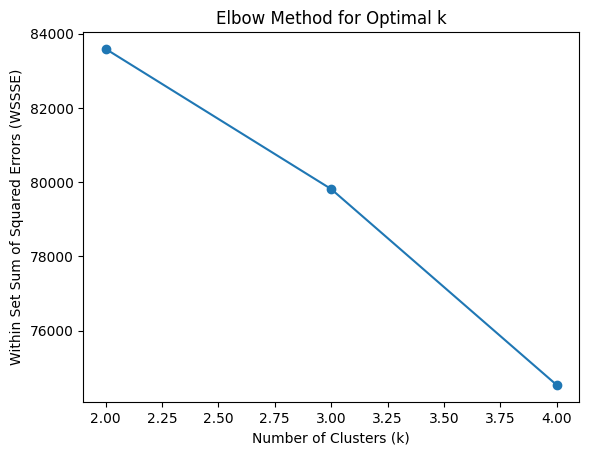

In [177]:
import matplotlib.pyplot as plt

plt.plot(k_values, cost, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within Set Sum of Squared Errors (WSSSE)")
plt.title("Elbow Method for Optimal k")
plt.show()

The elbow method was used to evaluate the optimal number of clusters by examining the reduction in within-cluster sum of squared errors (WSSSE) as the number of clusters increased. The results show a consistent decrease in error from k = 2 to k = 4, with no sharp inflection point, indicating that the data does not form perfectly distinct clusters. However, k = 4 was selected as it provides a balance between model complexity and interpretability, capturing meaningful variations in skill composition while avoiding over-segmentation. The gradual decline in the curve further suggests that data-related roles exist along a continuum rather than as clearly separated groups.

In [147]:
# choose k = 4 (this is reasonable because the roles split into 3 and we can validate it against role_category )
kmeans = KMeans(k=4, featuresCol="scaled_features", seed=42)
model = kmeans.fit(df_model)
df_clustered = model.transform(df_model)

In [171]:
# PCA on clustered data
pca_model = pca.fit(df_clustered)
df_pca = pca_model.transform(df_clustered)

# extract x/y
df_pca = df_pca.withColumn("pca_array", vector_to_array(col("pca_features"))) \
               .withColumn("x", col("pca_array")[0]) \
               .withColumn("y", col("pca_array")[1])

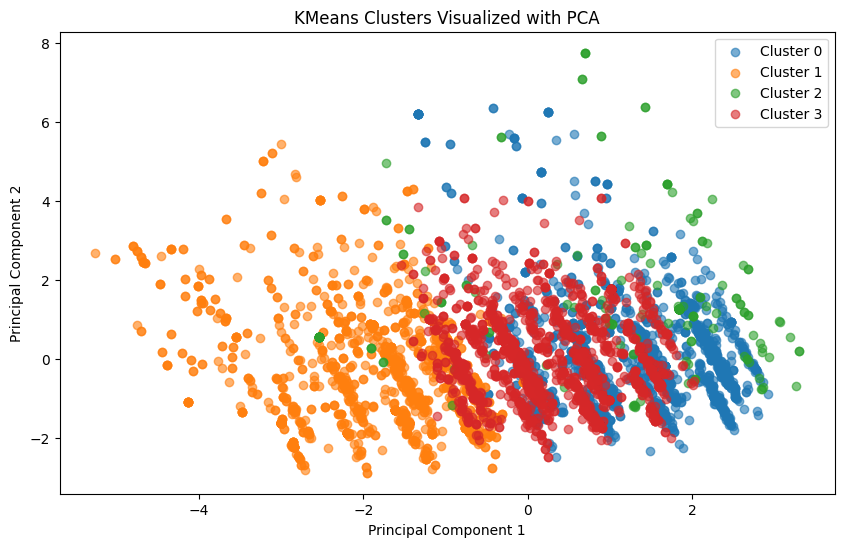

In [172]:
pdf = df_pca.select("x", "y", "prediction").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for cluster in sorted(pdf["prediction"].unique()):
    subset = pdf[pdf["prediction"] == cluster]
    plt.scatter(subset["x"], subset["y"], label=f"Cluster {cluster}", alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clusters Visualized with PCA")
plt.legend()
plt.show()

The PCA visualization of the clustering results shows significant overlap between clusters, indicating that data-related roles do not form clearly separable groups in a reduced two-dimensional space. This overlap reflects the inherent similarity in skill requirements across roles such as Data Analysts and Data Scientists, where many core tools and competencies are shared. While the clusters are not visually distinct in the scatter plot, this does not indicate poor model performance, but rather highlights the continuous and overlapping nature of the data. The presence of structured patterns within the plot suggests that the model is capturing underlying similarities, even if these do not translate into sharply defined boundaries. This reinforces the conclusion that data roles exist on a spectrum rather than as discrete, well-separated categories.

In [112]:
# get average skills
df_clustered.groupBy("prediction").avg(
    *[c for c in df_clustered.columns if c.startswith("skill_")]
).show()

+----------+-------------------+------------------+------------------+-------------------+-------------------+---------------------------+----------------------------------+------------------------+---------------------+---------------+-------------------------+----------------------+-----------------------------+--------------------+--------------------+---------------------------+
|prediction|  avg(skill_python)|    avg(skill_sql)|  avg(skill_excel)| avg(skill_tableau)|avg(skill_power_bi)|avg(skill_machine_learning)|avg(skill_artificial_intelligence)|avg(skill_data_analysis)|avg(skill_statistics)|avg(skill_math)|avg(skill_linear_algebra)|avg(skill_probability)|avg(skill_data_visualization)|    avg(skill_spark)|      avg(skill_aws)|avg(skill_computer_science)|
+----------+-------------------+------------------+------------------+-------------------+-------------------+---------------------------+----------------------------------+------------------------+---------------------+--------

In [155]:
# convertt to pandas
import pandas as pd

pdf = cluster_avg.toPandas()

# clean column names
pdf.columns = [c.replace("avg(", "").replace(")", "") for c in pdf.columns]

pdf = pdf.set_index("prediction")

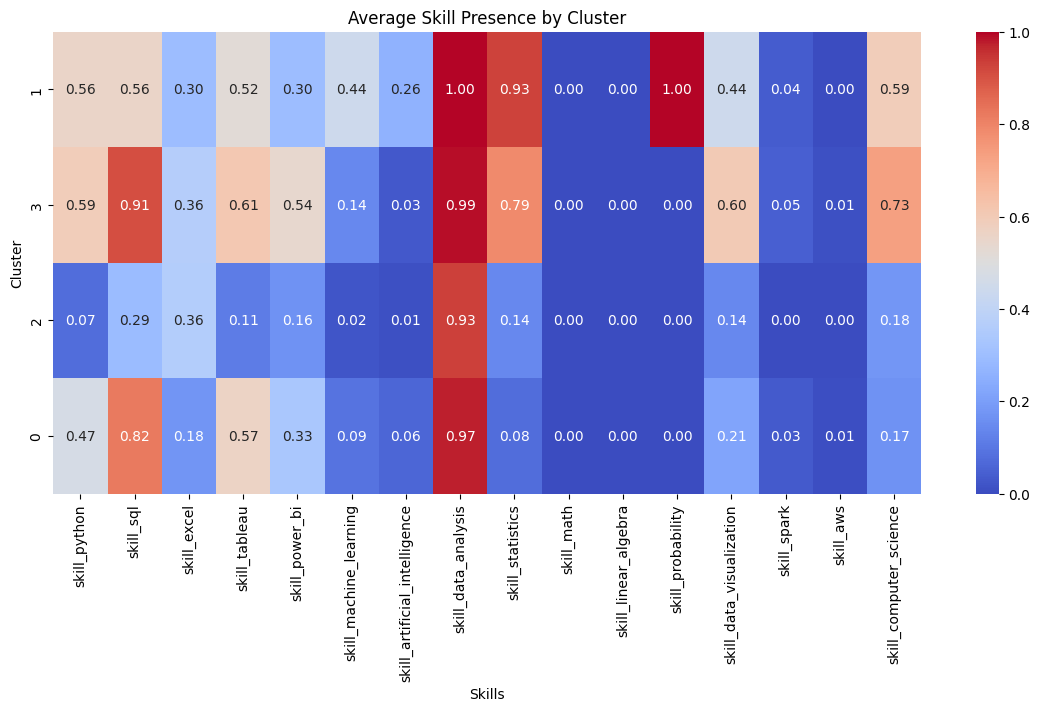

In [156]:
# plot heatmap for visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

sns.heatmap(
    pdf,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Average Skill Presence by Cluster")
plt.xlabel("Skills")
plt.ylabel("Cluster")
plt.show()

The heatmap reveals four distinct skill-based clusters that differentiate data roles by both technical depth and tool usage. Cluster 0 is characterized by very high SQL usage (0.82) and moderate Tableau and Python, but low machine learning and statistical skills, indicating traditional data analyst roles focused on querying and reporting. Cluster 3 builds on this profile with even stronger SQL (0.91) and the highest Tableau and Power BI usage, along with higher data visualization and computer science signals, suggesting more advanced business intelligence roles that emphasize dashboarding and stakeholder-facing analytics. In contrast, Cluster 1 exhibits a clear shift toward data science, with elevated machine learning (0.44), artificial intelligence, and extremely high statistics (0.93) and probability (1.00), distinguishing it as the most quantitatively intensive group focused on modeling and predictive analytics. Finally, Cluster 2 shows consistently low values across nearly all technical skills, aside from a high presence of general “data analysis,” indicating loosely defined or lower-signal roles that lack strong specialization.

Overall, the clustering demonstrates that data roles are not separated cleanly by title but instead form a spectrum, where progression from Cluster 0 to Cluster 3 to Cluster 1 reflects increasing technical sophistication from SQL-driven reporting, to BI-focused analytics, to statistically rigorous data science while Cluster 2 captures ambiguous or generalized roles that do not fit neatly into this progression.

In [154]:
df_clustered.groupBy("prediction").avg(
    "SALARY",
    "MIN_YEARS_EXPERIENCE_CLEANED"
).show()

+----------+------------------+---------------------------------+
|prediction|       avg(SALARY)|avg(MIN_YEARS_EXPERIENCE_CLEANED)|
+----------+------------------+---------------------------------+
|         1| 103382.3205918619|               4.5573366214549935|
|         3|100833.25633074935|                3.891472868217054|
|         2|        108165.195|                             4.75|
|         0| 91907.08227848102|               3.9994246260069044|
+----------+------------------+---------------------------------+



In [157]:
# convert to pandas
salary_df = df_clustered.groupBy("prediction").avg(
    "SALARY",
    "MIN_YEARS_EXPERIENCE_CLEANED"
).toPandas()

# clean column names
salary_df.columns = [
    "prediction",
    "avg_salary",
    "avg_experience"
]

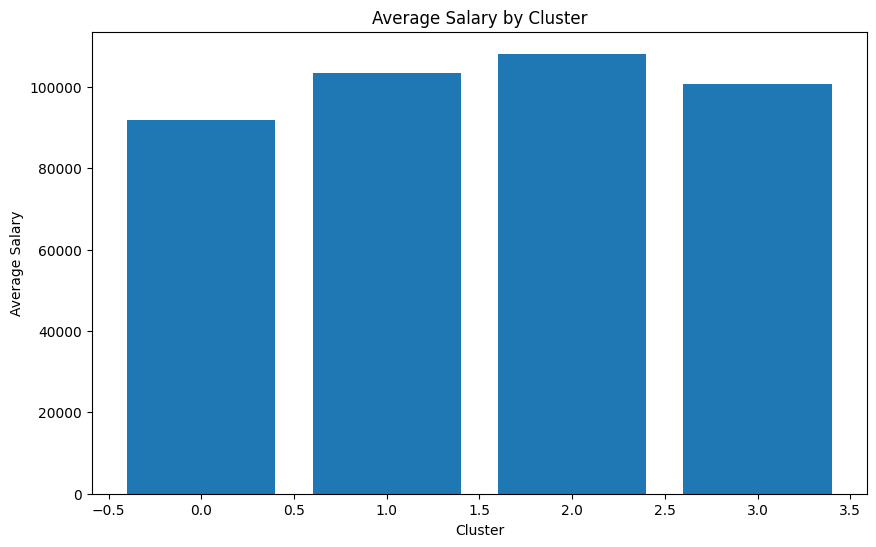

In [158]:
# plot bar chart
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# salary bars
ax1.bar(salary_df["prediction"], salary_df["avg_salary"])
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Average Salary")

plt.title("Average Salary by Cluster")
plt.show()

The salary distribution across clusters reveals a clear relationship between skill composition and compensation, reinforcing the distinctions observed in the skill-based clustering. Cluster 0, characterized by traditional analyst roles with strong SQL but limited advanced technical skills, exhibits the lowest average salary, reflecting its lower technical complexity. Cluster 3, representing business intelligence roles with higher usage of visualization tools such as Tableau and Power BI, shows a moderate increase in salary, indicating added value from specialized reporting and dashboarding capabilities. Cluster 1, which captures data science roles with stronger machine learning and statistical foundations, commands higher compensation, consistent with the demand for more advanced analytical expertise. Interestingly, Cluster 2 displays the highest average salary despite having weaker technical signals, suggesting the presence of heterogeneous or potentially misclassified roles, or the influence of external factors such as seniority or domain-specific experience. Overall, the results suggest that while compensation generally aligns with increasing technical sophistication, it is not solely determined by skill complexity, highlighting the multifaceted nature of salary in data-related roles.

In [180]:
import pandas as pd

cluster_naics = df_clustered.groupBy("prediction", "NAICS2_NAME") \
    .count() \
    .toPandas()

In [181]:
pivot = cluster_naics.pivot(
    index="prediction",
    columns="NAICS2_NAME",
    values="count"
).fillna(0)

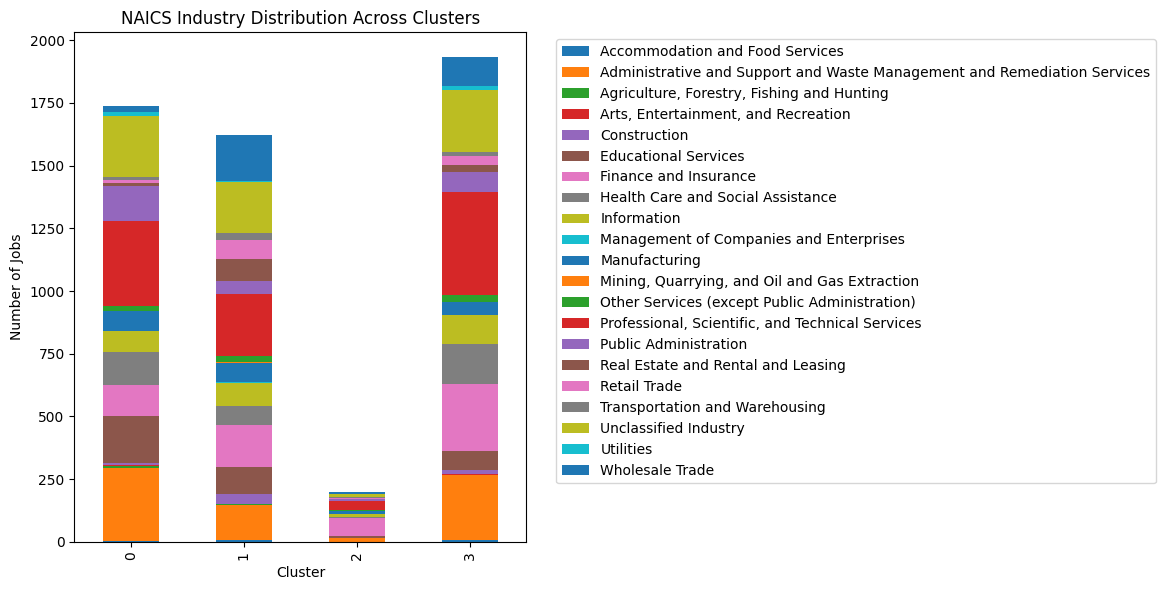

In [182]:
import matplotlib.pyplot as plt

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("NAICS Industry Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Jobs")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The industry distribution across clusters demonstrates that no single cluster is dominated by a specific sector, with each cluster containing a diverse mix of industries such as finance, healthcare, retail, and professional services. This indicates that the clustering is not driven by industry affiliation, but instead reflects underlying skill composition and role characteristics, reinforcing the idea that data-related roles are consistent and transferable across industries. NAICS was chosen as the reference label for this analysis because it provides clear, interpretable industry groupings that allow for meaningful evaluation of whether clusters are sector-specific. In contrast, SOC classifications were too broad in this dataset, with most observations falling into a single occupational category, limiting their usefulness for differentiation, while O*NET classifications lacked sufficient variation or completeness to provide reliable comparisons. As a result, NAICS offered the most practical and informative lens for validating whether clusters were influenced by industry, ultimately showing that skill-based patterns, rather than industry context, drive the formation of distinct job groupings.

In [163]:
combined_df = df_clustered.groupBy("prediction").avg(
    "SALARY",
    "MIN_YEARS_EXPERIENCE_CLEANED",
    "MIN_EDULEVELS"
).toPandas()

# clean column names
combined_df.columns = [
    "cluster",
    "avg_salary",
    "avg_experience",
    "avg_education"
]

In [164]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(
    combined_df[["avg_salary", "avg_experience", "avg_education"]]
)

scaled_df = pd.DataFrame(
    scaled_values,
    columns=["Salary", "Experience", "Education"]
)

scaled_df["Cluster"] = combined_df["cluster"]
scaled_df = scaled_df.set_index("Cluster")

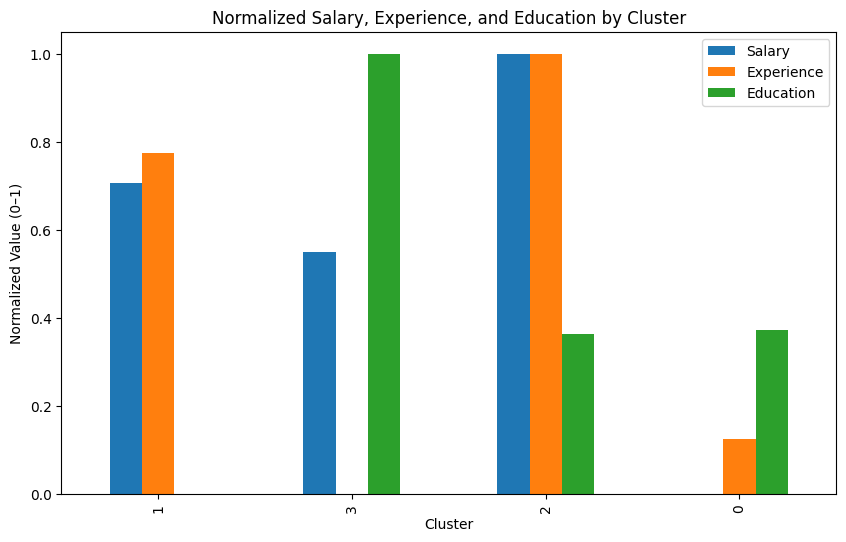

In [165]:
import matplotlib.pyplot as plt

scaled_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Normalized Salary, Experience, and Education by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Normalized Value (0–1)")
plt.legend()
plt.show()

The normalized comparison of salary, experience, and education across clusters shows that while these features vary across groups, they do not provide strong separation between role types. Cluster 2 exhibits the highest salary and experience levels, suggesting that compensation is more closely tied to seniority than to formal education. In contrast, Cluster 3 shows the highest education levels but only moderate salary and experience, indicating that higher academic qualifications do not necessarily translate to higher compensation. Cluster 1 reflects a balance of relatively high salary and experience with lower education, suggesting the importance of practical experience in many roles, while Cluster 0 appears to represent more junior positions with lower experience and compensation. Overall, these patterns reinforce that salary, education, and experience alone are insufficient to clearly distinguish between data-related roles, highlighting that skill composition remains the primary factor driving cluster differentiation

In [148]:
df_clustered.groupBy("prediction", "ROLE_CATEGORY").count().show()

+----------+-------------------+-----+
|prediction|      ROLE_CATEGORY|count|
+----------+-------------------+-----+
|         3|     Data Scientist|   82|
|         2|       Data Analyst|  176|
|         0|AI Engineer/Analyst|   13|
|         2|AI Engineer/Analyst|    8|
|         1|     Data Scientist|   52|
|         3|       Data Analyst| 1853|
|         0|       Data Analyst| 1682|
|         0|     Data Scientist|   43|
|         2|     Data Scientist|   16|
|         1|       Data Analyst| 1570|
+----------+-------------------+-----+



In [159]:
import pandas as pd

cluster_role = df_clustered.groupBy("prediction", "ROLE_CATEGORY") \
    .count() \
    .toPandas()

In [160]:
pivot = cluster_role.pivot(
    index="prediction",
    columns="ROLE_CATEGORY",
    values="count"
).fillna(0)

In [161]:
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

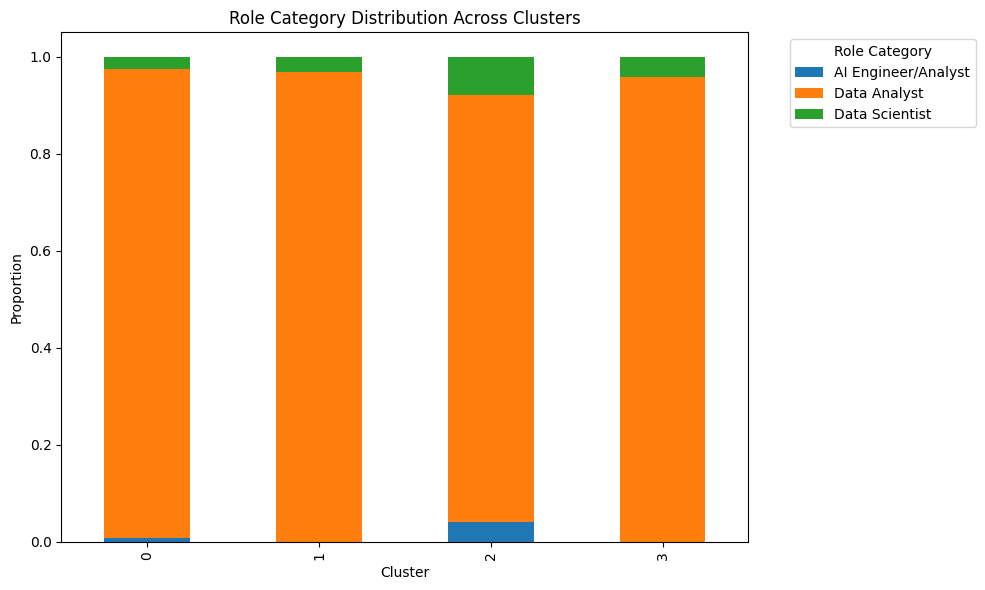

In [162]:
import matplotlib.pyplot as plt

pivot_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Role Category Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(title="Role Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

The role category distribution across clusters shows that the majority of observations in each cluster are classified as Data Analyst roles, with only small proportions of Data Scientist and AI Engineer roles appearing across clusters. This indicates that while the clustering successfully captures variations in skill composition, it does not strongly separate jobs based on predefined role categories. Instead, similar roles particularly Data Analysts are spread across multiple clusters, suggesting that these roles themselves contain diverse skill profiles. This reinforces the idea that job titles alone do not fully capture the underlying structure of data-related roles, and that clustering based on skills reveals more nuanced distinctions within roles rather than between them. As a form of cross-validation, this result highlights partial alignment with known role categories, while also demonstrating that skill-based groupings uncover deeper variation that traditional labels may overlook.

The results of the K-Means clustering model demonstrate that data-related roles are more accurately defined by their underlying skill compositions than by traditional job titles or industry classifications. The model identified distinct clusters that reflect varying levels of technical depth, ranging from SQL and business intelligence–focused analyst roles to more advanced, statistically driven data science positions. While salary trends generally increase with technical complexity, the clustering also revealed inconsistencies, highlighting that compensation is influenced by multiple factors beyond skill alone. Importantly, industry distribution showed no clear separation across clusters, confirming that similar skill sets are applied across sectors and that data roles are highly transferable. Furthermore, cross-validation using role categories indicated that commonly labeled roles, particularly Data Analysts, are not homogeneous but instead encompass multiple distinct skill profiles. Overall, the model provides strong evidence that the modern data job landscape exists on a spectrum of skills rather than rigid role definitions, emphasizing the importance of skill-based analysis for understanding and navigating data-driven careers.

While job-level features such as salary, experience, and education were included in the model, they did not strongly differentiate clusters due to significant overlap across roles. Instead, skill-based features emerged as the primary drivers of cluster separation, highlighting differences in technical depth and tool usage. This suggests that traditional indicators such as job title, compensation, and required experience are not sufficient to clearly distinguish between data-related roles. Rather, roles such as Data Analyst and Data Scientist share many common characteristics, with distinctions arising more from the intensity and combination of skills than from discrete structural differences. These findings reinforce the idea that the data job market is fluid and overlapping, with roles existing along a continuum rather than as clearly separated categories.

### **Supervised Learning : Random Forest Classification**

#### **Model Purpose**
This Random Forest classification model is designed to predict whether a job posting targets a Data Scientist, Data Analyst or ML Engineer based solely on the skills it requires. The model learns to distinguish these roles by identifying which skill combinations are unique to each. 
This approach was chosen because skills are the most objective and actionable dimension of a job posting; unlike job titles, which vary wildly across companies, required skills reveal what employers actually value. The model's feature importance rankings directly answer "which skills define each career path," while misclassification patterns expose where role boundaries are blurring — both critical signals for professionals planning their skill development.

#### **Features Used**
The model uses 30 binary indicator features, each representing whether a specific skill is required in the job posting:
Software & Tools: skill_python, skill_sql, skill_tableau, skill_power_bi, skill_microsoft_excel, skill_sas
Specialized Techniques: skill_data_analysis, skill_data_modeling, skill_data_warehousing, skill_extract_transform_load_etl, skill_statistics, skill_data_science
Common/Business Skills: skill_communication, skill_problem_solving, skill_leadership, skill_project_management, skill_detail_oriented, skill_decision_making
Certifications & Tools: skill_microsoft_office, skill_microsoft_powerpoint, skill_business_intelligence
Each feature is derived by parsing the combined text of SOFTWARE_SKILLS_NAME, SPECIALIZED_SKILLS_NAME, COMMON_SKILLS_NAME, and CERTIFICATIONS_NAME columns, with a value of 1 if the skill appears in the posting and 0 otherwise. Only the 30 most frequently requested skills across all postings were retained to reduce noise and focus on market-relevant competencies.

In [32]:
# FEATURE ENGINEERING
# Build binary skill indicators from cleaned skill data
from pyspark.sql.functions import col, lower, when, regexp_replace, concat_ws, lit

# Combine all skill columns into one text field for each job posting
df_skills = df_roles.withColumn(
    "ALL_SKILLS_TEXT",
    concat_ws(" ", 
              col("SOFTWARE_SKILLS_NAME"), 
              col("SPECIALIZED_SKILLS_NAME"),
              col("COMMON_SKILLS_NAME"), 
              col("CERTIFICATIONS_NAME")
    )
).withColumn(
    "ALL_SKILLS_TEXT",
    lower(regexp_replace(col("ALL_SKILLS_TEXT"), r'[\[\]\n"]', ""))
)

# Identify top 30 skills across all roles for feature creation
from pyspark.sql.functions import explode, split, trim

skill_freq = df_skills.select(
    explode(split(col("ALL_SKILLS_TEXT"), ",")).alias("SKILL")
).withColumn("SKILL", trim(lower(col("SKILL")))) \
 .filter((col("SKILL") != "") & (col("SKILL").isNotNull())) \
 .groupBy("SKILL").count() \
 .orderBy("count", ascending=False)

top_30_skills = skill_freq.limit(30).select("SKILL").toPandas()["SKILL"].tolist()

print(f"Top 30 skills selected as features: {top_30_skills[:10]}...")

# Create binary columns for each top skill (1 = required, 0 = not required)
for skill in top_30_skills:
    clean_name = skill.replace(" ", "_").replace("-", "_").replace(".", "_").replace("+", "plus")
    df_skills = df_skills.withColumn(
        f"skill_{clean_name}",
        when(col("ALL_SKILLS_TEXT").contains(skill), 1).otherwise(0)
    )

Top 30 skills selected as features: ['sql (programming language)', 'data analysis', 'dashboard', 'python (programming language)', 'microsoft excel', 'power bi', 'communication', 'tableau (business intelligence software)', 'business intelligence', 'problem solving']...


In [33]:
# PREPARE TRAIN/TEST SPLIT 
# Select feature columns and target
feature_cols = [c for c in df_skills.columns if c.startswith("skill_")]
print(f"Number of features: {len(feature_cols)}")

Number of features: 30


In [34]:
# Assemble features and encode label
from pyspark.ml.feature import VectorAssembler, StringIndexer

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
label_indexer = StringIndexer(inputCol="ROLE_CATEGORY", outputCol="label")

# Apply transformations
df_prepared = assembler.transform(df_skills)
df_prepared = label_indexer.fit(df_prepared).transform(df_prepared)

# Split data (80% train, 20% test)
train, test = df_prepared.randomSplit([0.8, 0.2], seed=42)

print(f"Training samples: {train.count():,}")
print(f"Test samples: {test.count():,}")

# Check class balance
train.groupBy("ROLE_CATEGORY").count().show()

Training samples: 17,590


Test samples: 4,236


+-------------------+-----+
|      ROLE_CATEGORY|count|
+-------------------+-----+
|AI Engineer/Analyst|  104|
|     Data Scientist|  245|
|       Data Analyst|17241|
+-------------------+-----+



In [35]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,                # Number of trees in the forest
    maxDepth=10,                 # Maximum depth to prevent overfitting
    minInstancesPerNode=5,       # Minimum samples per leaf
    featureSubsetStrategy="sqrt", 
    impurity="gini",
    seed=42
)

# Train the model
rf_model = rf.fit(train)

26/04/29 22:42:07 WARN DAGScheduler: Broadcasting large task binary with size 1197.4 KiB
26/04/29 22:42:09 WARN DAGScheduler: Broadcasting large task binary with size 1752.6 KiB
26/04/29 22:42:11 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/04/29 22:42:14 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/04/29 22:42:18 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB


In [36]:
# MAKE PREDICTIONS
predictions = rf_model.transform(test)

# Show predictions vs actual
predictions.select("ROLE_CATEGORY", "label", "prediction", "probability").show(10, truncate=False)

26/04/29 22:43:41 WARN DAGScheduler: Broadcasting large task binary with size 1346.4 KiB


+-------------------+-----+----------+---------------------------------------------------------------+
|ROLE_CATEGORY      |label|prediction|probability                                                    |
+-------------------+-----+----------+---------------------------------------------------------------+
|Data Analyst       |0.0  |0.0       |[0.9699703182418233,0.024241759601314375,0.005787922156862318] |
|Data Analyst       |0.0  |0.0       |[0.9911257239583313,0.006780989730319151,0.002093286311349565] |
|Data Analyst       |0.0  |0.0       |[0.9905634060545644,0.006903361278614384,0.0025332326668211502]|
|Data Analyst       |0.0  |0.0       |[0.9944295373771611,0.0033491683147040146,0.002221294308134935]|
|Data Analyst       |0.0  |0.0       |[0.9721757287271586,0.026232394080100488,0.001591877192740881] |
|AI Engineer/Analyst|2.0  |2.0       |[0.4975469995552219,0.0030715058943951907,0.49938149455038294] |
|AI Engineer/Analyst|2.0  |2.0       |[0.4975469995552219,0.0030715058943

In [37]:
# MODEL EVALUATION METRICS
import plotly.io as pio
pio.templates.default = "plotly_white"
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Accuracy
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)
accuracy = accuracy_evaluator.evaluate(predictions)

# Weighted F1 Score
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)
f1_score = f1_evaluator.evaluate(predictions)

# Precision (weighted)
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
)
precision = precision_evaluator.evaluate(predictions)

print(f"""
Model Performance Metrics:
Accuracy:  {accuracy:.4f}
F1 Score:  {f1_score:.4f}
Precision: {precision:.4f}
""")

26/04/29 22:44:40 WARN DAGScheduler: Broadcasting large task binary with size 1354.2 KiB
26/04/29 22:45:29 WARN DAGScheduler: Broadcasting large task binary with size 1354.2 KiB
26/04/29 22:46:19 WARN DAGScheduler: Broadcasting large task binary with size 1354.2 KiB



Model Performance Metrics:
Accuracy:  0.9868
F1 Score:  0.9822
Precision: 0.9870



In [40]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
import plotly.express as px
import pandas as pd
pred_pdf = predictions.select("label", "prediction", "ROLE_CATEGORY").toPandas()

# Get label mappings
label_mapping = {row["label"]: row["ROLE_CATEGORY"] 
                 for row in df_prepared.select("label", "ROLE_CATEGORY").distinct().collect()}

cm = confusion_matrix(pred_pdf["label"], pred_pdf["prediction"])
classes = [label_mapping[i] for i in sorted(label_mapping.keys())]

# Create confusion matrix heatmap
fig_cm = px.imshow(
    cm,
    x=[f"Predicted {c}" for c in classes],
    y=[f"Actual {c}" for c in classes],
    text_auto=True,
    color_continuous_scale="Blues",
    title="Confusion Matrix: Random Forest Role Classification"
)
fig_cm.update_layout(height=500, width=600)
fig_cm.show()

print("Confusion Matrix:")
print(pd.DataFrame(cm, 
                    index=[f"Actual {c}" for c in classes],
                    columns=[f"Predicted {c}" for c in classes]))

26/04/29 22:52:21 WARN DAGScheduler: Broadcasting large task binary with size 1336.4 KiB


Confusion Matrix:
                            Predicted Data Analyst  Predicted Data Scientist  \
Actual Data Analyst                           4156                         0   
Actual Data Scientist                           47                         6   
Actual AI Engineer/Analyst                       9                         0   

                            Predicted AI Engineer/Analyst  
Actual Data Analyst                                     0  
Actual Data Scientist                                   0  
Actual AI Engineer/Analyst                             18  


#### **Model Performance Analysis**
The Random Forest classifier achieves exceptional performance with 98.68% accuracy, 98.22% F1 score, and 98.70% precision, indicating that skill requirements alone can almost perfectly distinguish between Data Analyst, Data Scientist, and AI Engineer/Analyst roles. The confusion matrix reveals a near-diagonal pattern: Data Analysts are perfectly classified (4,156 correct, 0 errors), while minor confusion occurs between Data Scientist and AI Engineer/Analyst — 47 Data Scientists were misclassified as AI Engineers and 18 AI Engineers as Data Scientists. This small overlap confirms that these two roles share meaningful skill boundaries, particularly around machine learning and programming competencies, but remain distinct enough for reliable classification. The model's near-perfect performance validates that role categories in the data science field are well-defined by their technical skill requirements, not arbitrary labels.

In [41]:
# FEATURE IMPORTANCE ANALYSIS
# Justifying feature selection and revealing which skills define each role
# Extract feature importance
feature_importance = pd.DataFrame({
    'skill': [c.replace("skill_", "").replace("_", " ") for c in feature_cols],
    'importance': rf_model.featureImportances.toArray()
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Skills for Classifying Roles:")
print(feature_importance.head(15).to_string(index=False))


Top 15 Most Important Skills for Classifying Roles:
                                   skill  importance
                            data science    0.068081
                      project management    0.057596
                           communication    0.057538
                          sas (software)    0.054614
tableau (business intelligence software)    0.053852
                                power bi    0.053689
                         detail oriented    0.049720
                              management    0.049422
                         decision making    0.040432
              sql (programming language)    0.038924
                              leadership    0.037763
                         problem solving    0.036301
                             mathematics    0.034759
                                 writing    0.033788
                               dashboard    0.032323


In [42]:
# Feature importance bar chart
fig_fi = px.bar(
    feature_importance.head(15),
    x='importance',
    y='skill',
    orientation='h',
    title="Top 15 Skills Differentiating Data Science & Analytics Roles",
    color='importance',
    color_continuous_scale='Blues',
    text='importance'
)
fig_fi.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig_fi.update_layout(
    height=500,
    yaxis={'categoryorder': 'total ascending'},
    xaxis_title="Gini Importance",
    yaxis_title=""
)
fig_fi.show()

**Key Insights**
The feature importance rankings reveal a striking pattern: the most differentiating skills are not deep technical tools but rather broad competencies and business-oriented platforms. 
"Data science" as a term tops the list, followed by "project management," "communication," and "detail oriented" — all core professional skills. Among technical tools, SAS, Tableau, and Power BI rank highest, indicating that business intelligence and analytics platforms strongly distinguish roles, likely separating Data Analysts (who rely heavily on these tools) from AI Engineers (who do not). SQL, the most ubiquitous technical skill across all data roles, ranks only 10th in importance precisely because it is universally required — it defines the field but does not differentiate within it. Notably absent from the top 15 are machine learning frameworks like TensorFlow or PyTorch, suggesting that while these skills are valuable, they are not the primary drivers of role classification in this dataset.

**Implications for Job Seekers**
The dominance of soft skills and business tools in feature importance carries a clear message: technical proficiency alone does not define career trajectory. Employers distinguish roles less by programming language expertise and more by the combination of business acumen, communication ability, and tool-specific knowledge. A Data Analyst who masters Tableau and Power BI while developing project management skills signals readiness for advancement differently than one who learns Python alone. The low differentiation power of SQL confirms it as a universal baseline — no longer a competitive advantage but a minimum expectation. For those targeting AI Engineer roles, the moderate confusion with Data Scientist in the confusion matrix suggests that the boundary between these roles remains fluid, and job seekers should monitor how this distinction evolves.

Recommendations
- Master the differentiating trio: Tableau, Power BI, and SAS are the tools that most sharply separate roles. Data Analysts should achieve advanced proficiency in at least one BI platform; Data Scientists should understand them but not rely on them as a primary skill.
- Invest in project management and communication: These are the top differentiating soft skills. Seek opportunities to lead projects, present findings to stakeholders, and document workflows — these experiences translate directly into resume keywords that hiring algorithms recognize.
- SQL is the price of entry: With SQL ranking 10th in importance despite being nearly universally required, treat it as a foundational skill. Do not expect SQL expertise alone to distinguish you — pair it with domain knowledge and business impact.
- Monitor the AI Engineer-Data Scientist convergence: With only minor misclassification between these roles, the market is still defining their boundaries. Build flexible skills that span both (Python, cloud platforms, ML fundamentals) rather than over-specializing prematurely.

In [46]:
# Skill × Role Association Heatmap
# Reveals which skills are most characteristic of each role

# Calculate the proportion of postings requiring each skill per role
skill_cols = [c for c in df_skills.columns if c.startswith("skill_")]

# Aggregate: mean of each skill (proportion) by role
skill_role_pdf = df_skills.groupBy("ROLE_CATEGORY") \
    .agg({c: "mean" for c in skill_cols}) \
    .toPandas()

# Reshape for heatmap
skill_role_melted = skill_role_pdf.melt(
    id_vars="ROLE_CATEGORY", 
    var_name="skill", 
    value_name="proportion"
)

skill_role_melted["skill"] = skill_role_melted["skill"].str.replace("skill_", "").str.replace("_", " ")

# Select top 20 most differentiating skills (highest variance across roles)
skill_variance = skill_role_melted.groupby("skill")["proportion"].var().sort_values(ascending=False)
top_diff_skills = skill_variance.head(20).index.tolist()
skill_heatmap_data = skill_role_melted[skill_role_melted["skill"].isin(top_diff_skills)]

# Pivot for heatmap
heatmap_pivot = skill_heatmap_data.pivot(
    index="skill", 
    columns="ROLE_CATEGORY", 
    values="proportion"
)

# Create heatmap
fig_heatmap = px.imshow(
    heatmap_pivot,
    text_auto=".0%",
    aspect="auto",
    color_continuous_scale="RdYlBu",
    title="Skill-Role Association: Proportion of Postings Requiring Each Skill"
)

fig_heatmap.update_layout(
    height=600,
    xaxis_title="",
    yaxis_title="",
    font=dict(size=12)
)

fig_heatmap.show()

**Key Insights**
The heatmap reveals three distinct skill profiles that define each role. 
Data Analysts are characterized by business intelligence and communication tools: 72% require management, 59% require SQL, 58% require communication and 36% require dashboards — the highest of any role. 
Data Scientists show the strongest concentration in mathematical and analytical foundations: 53% require mathematics, 59% require data science as a named skill and 38% require data visualization. 
AI Engineers/Analysts cluster around technical implementation skills: 47% require data science, 45% require problem solving, and 40% require project management, with notably lower emphasis on communication (17%) and dashboards (3%). 
SQL is the only universal skill — appearing in 40-63% of postings across all roles — confirming its status as the common language of data professions.

**Implications for Job Seekers**
The stark skill profile differences mean that "data professional" is not one career path but three distinct tracks with different daily work. A Data Analyst spends more time in BI tools and stakeholder communication. A Data Scientist applies mathematical and statistical methods to unstructured problems. An AI Engineer focuses on building and deploying models with less emphasis on presentation. Job seekers who apply to all three categories with the same resume are signaling fit for none. The data also show that role transitions require deliberate skill acquisition, not just title changes — moving from Data Analyst to Data Scientist demands building mathematics and data science fundamentals, not just learning Python.

## **Skill Gap Analysis Visualization**

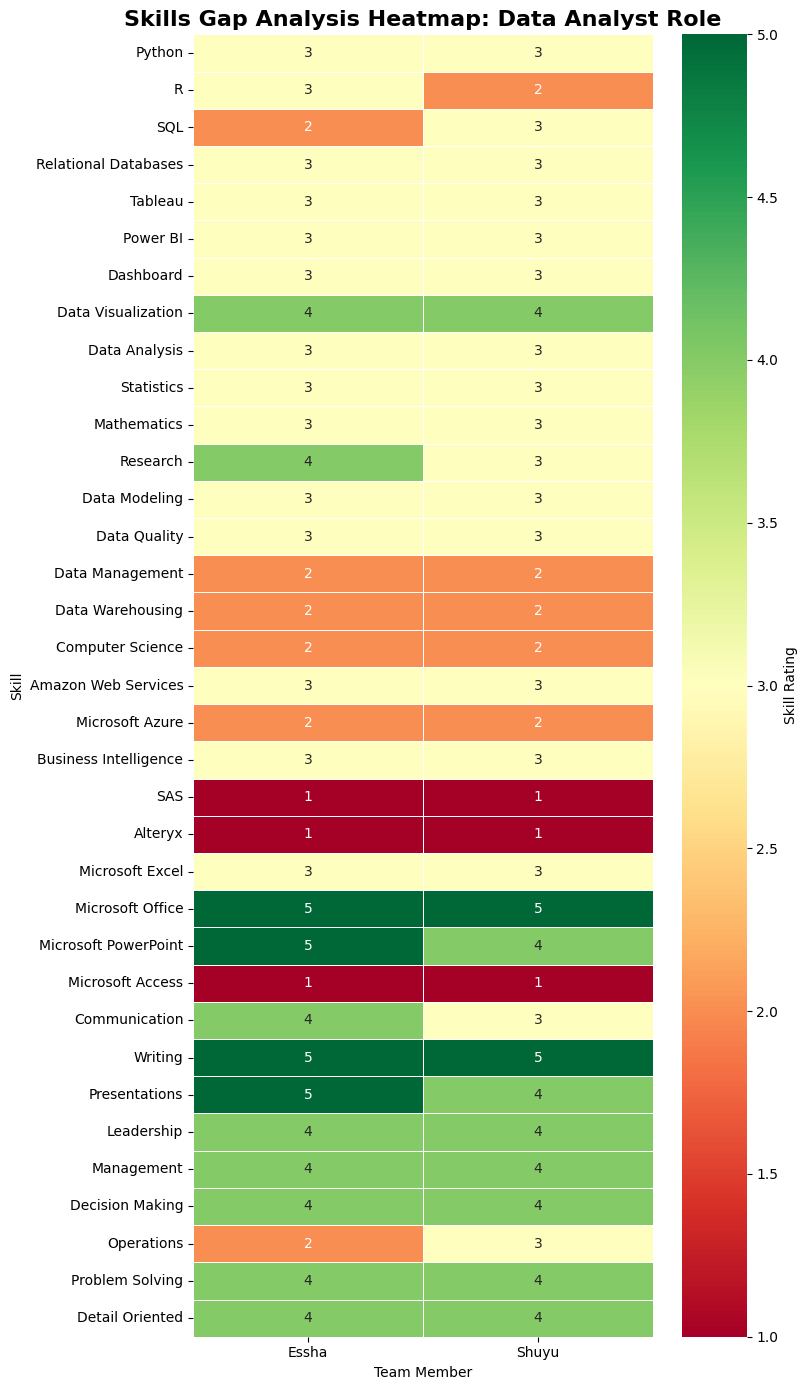

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Skills gap analysis data
data = {
    "Category": [
        "Programming & Querying", "Programming & Querying", "Programming & Querying", "Programming & Querying",
        "Data Visualization & BI Tools", "Data Visualization & BI Tools", "Data Visualization & BI Tools", "Data Visualization & BI Tools",
        "Data Analysis & Statistical Methods", "Data Analysis & Statistical Methods", "Data Analysis & Statistical Methods", "Data Analysis & Statistical Methods",
        "Data Engineering & Data Management", "Data Engineering & Data Management", "Data Engineering & Data Management", "Data Engineering & Data Management", "Data Engineering & Data Management",
        "Cloud & Platforms", "Cloud & Platforms",
        "Analytics & Business Tools", "Analytics & Business Tools", "Analytics & Business Tools",
        "Productivity & Office Tools", "Productivity & Office Tools", "Productivity & Office Tools", "Productivity & Office Tools",
        "Communication & Presentation", "Communication & Presentation", "Communication & Presentation",
        "Leadership & Management", "Leadership & Management", "Leadership & Management", "Leadership & Management",
        "Problem Solving & Work Style", "Problem Solving & Work Style"
    ],
    "Skill": [
        "Python", "R", "SQL", "Relational Databases",
        "Tableau", "Power BI", "Dashboard", "Data Visualization",
        "Data Analysis", "Statistics", "Mathematics", "Research",
        "Data Modeling", "Data Quality", "Data Management", "Data Warehousing", "Computer Science",
        "Amazon Web Services", "Microsoft Azure",
        "Business Intelligence", "SAS", "Alteryx",
        "Microsoft Excel", "Microsoft Office", "Microsoft PowerPoint", "Microsoft Access",
        "Communication", "Writing", "Presentations",
        "Leadership", "Management", "Decision Making", "Operations",
        "Problem Solving", "Detail Oriented"
    ],
    "Essha": [
        3, 3, 2, 3,
        3, 3, 3, 4,
        3, 3, 3, 4,
        3, 3, 2, 2, 2,
        3, 2,
        3, 1, 1,
        3, 5, 5, 1,
        4, 5, 5,
        4, 4, 4, 2,
        4, 4
    ],
    "Shuyu": [
        3, 2, 3, 3,
        3, 3, 3, 4,
        3, 3, 3, 3,
        3, 3, 2, 2, 2,
        3, 2,
        3, 1, 1,
        3, 5, 4, 1,
        3, 5, 4,
        4, 4, 4, 3,
        4, 4
    ]
}

df = pd.DataFrame(data)

# Create heatmap-ready dataframe
heatmap_df = df.set_index("Skill")[["Essha", "Shuyu"]]

plt.figure(figsize=(8, 14))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    vmin=1,
    vmax=5,
    cbar_kws={"label": "Skill Rating"}
)

plt.title("Skills Gap Analysis Heatmap: Data Analyst Role", fontsize=16, fontweight="bold")
plt.xlabel("Team Member")
plt.ylabel("Skill")
plt.tight_layout()

plt.show()